# Прогноз отмены бронирования для сети отелей UrbanStay

## Цель проекта

Построить модель, которая оценивает вероятность отмены бронирования и помогает UrbanStay снизить финансовые потери от поздних отмен.

Качество решения оценивается через бизнес-эффект:

- снижение доли отмен после внедрения модели до **10%**;
- сохранение загрузки отеля, падение не больше **8%**;
- относительный прирост дохода не меньше **50%**;
- максимизация **Incremental Revenue, IR**.

---

## План работы

### 1. Загрузка данных

Загрузить из PostgreSQL две таблицы:

- `hotel_bookings` - история бронирований;
- `hotel_reviews` - отзывы гостей.

---

### 2. Исследовательский анализ данных

Проверить:

- типы данных;
- пропуски;
- дубликаты;
- аномалии;
- баланс классов;
- распределения числовых признаков;
- распределения категориальных признаков.

Особое внимание уделить признакам:

- `booking_value`;
- `days_until_checkin`;
- `adult_count`;
- `child_count`;
- `weekend_nights`;
- `weekday_nights`;
- `previous_cancellations`;
- `customer_special_requests`;
- `booking_status`.

---

### 3. Объединение бронирований и отзывов

Для каждой брони нужно подтянуть ближайший предыдущий отзыв клиента.

Ключевое правило:

> Использовать только те отзывы, где `review_date < booking_date`.

Это нужно, чтобы избежать утечки данных из будущего. Если подтянуть отзыв, оставленный после даты бронирования, модель фактически получит информацию, которой на момент прогноза ещё не было.

---

### 4. Feature Engineering

Создать признаки из нескольких групп.

#### Признаки на основе бронирования

- общее количество гостей;
- общее количество ночей;
- доля выходных ночей;
- средняя стоимость одной ночи;
- средняя стоимость на гостя;
- флаг семейной поездки;
- флаг короткого проживания;
- флаг длинного проживания;
- флаг раннего бронирования;
- флаг бронирования в последний момент.

#### Признаки на основе истории клиента

- был ли клиент раньше;
- количество предыдущих отмен;
- количество предыдущих успешных заездов;
- отношение отмен к успешным заездам;
- флаг клиента с плохой историей отмен;
- флаг клиента без истории.

#### Признаки на основе дат

- месяц бронирования;
- сезон;
- день недели бронирования;
- флаг высокого сезона;
- флаг низкого сезона.

#### Признаки на основе отзывов

- последняя оценка проживания;
- давность последнего отзыва;
- наличие прошлого отзыва;
- длина текста отзыва;
- TF-IDF-признаки из `review_text`.


## Гипотезы

### Поведенческие гипотезы

1. Чем больше `days_until_checkin`, тем выше вероятность отмены.
   Длинный горизонт до заезда повышает шанс, что планы клиента изменятся.

2. Онлайн-бронирования могут отменяться чаще офлайн и корпоративных.
   Онлайн-канал снижает психологическую стоимость отмены: клиенту проще забронировать несколько вариантов и потом отказаться.

3. Повторные клиенты должны отменять реже новых.
   У них уже есть опыт проживания в сети, поэтому меньше неопределённости.

4. Клиенты с прошлыми отменами могут иметь повышенный риск новой отмены.
   История поведения часто сильнее параметров конкретной брони.

5. Наличие специальных пожеланий может снижать риск отмены.
   Если клиент оставил запросы, он, вероятно, сильнее вовлечён в поездку.


---

### Гипотезы по структуре бронирования

7. Короткие и длинные бронирования могут иметь разные паттерны отмен.
   Бронь на одну ночь проще отменить, а длинная поездка может быть более заранее спланированной.

8. Бронирования с детьми могут отменяться иначе, чем бронирования только для взрослых.
   Семейная поездка менее спонтанна, но более чувствительна к внешним обстоятельствам.

9. Высокая стоимость бронирования может иметь нелинейный эффект.
   Дорогие брони могут чаще отменяться из-за финансовой чувствительности, но самые дорогие брони могут быть более осознанными.

10. Тип номера может быть связан с риском отмены.
    Дешёвые и стандартные номера могут чаще бронироваться как запасной вариант.

11. Отношение выходных ночей к общему числу ночей может влиять на риск отмены.
    Поездки на выходные могут быть более гибкими и легче отменяться.

In [1]:
%pip install "autogluon.tabular[fastai]==1.5.0" -q
%pip install pytorch-tabnet -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import requests
import time
import re
import holidays

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_validate,
)
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

from sklearn.feature_extraction.text import CountVectorizer


from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

import phik
import optuna
from optuna.visualization import plot_optimization_history

import shap

import torch
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetClassifier
from autogluon.tabular import TabularPredictor


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [ ]:
import os

required_env = {
    'URBANSTAY_DB_USER': os.getenv('URBANSTAY_DB_USER'),
    'URBANSTAY_DB_PASSWORD': os.getenv('URBANSTAY_DB_PASSWORD'),
    'URBANSTAY_DB_HOST': os.getenv('URBANSTAY_DB_HOST'),
    'URBANSTAY_DB_PORT': os.getenv('URBANSTAY_DB_PORT', '6432'),
    'URBANSTAY_DB_NAME': os.getenv('URBANSTAY_DB_NAME'),
}

missing = [name for name, value in required_env.items() if not value]
if missing:
    raise RuntimeError(f"Заполните переменные окружения для подключения к БД: {', '.join(missing)}")

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    required_env['URBANSTAY_DB_USER'],
    required_env['URBANSTAY_DB_PASSWORD'],
    required_env['URBANSTAY_DB_HOST'],
    required_env['URBANSTAY_DB_PORT'],
    required_env['URBANSTAY_DB_NAME'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query_1 = '''
SELECT *
FROM hotel_bookings
'''

query_2 = '''
SELECT *
FROM hotel_reviews
'''

In [6]:
df_1 = pd.read_sql_query(query_1, con=engine)
df_2 = pd.read_sql_query(query_2, con=engine)
data = {
    "bookings": df_1,
    "reviews": df_2
}

for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))

========== bookings ==========


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0000,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0000,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0000,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0000,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0000,96,5,2,тип_питания_1,False,тип_1,1
35336,INN00327,2020-07-21,онлайн_бронирование,2,1,True,1,1,отказ_брони,13400.0000,259,2,0,тип_питания_1,False,тип_4,0
35337,INN13369,2018-11-12,офлайн_бронирование,1,0,False,0,0,нет_отказа,13400.0000,192,2,0,тип_питания_1,False,тип_1,2
35338,INN29068,2019-11-03,корпоративное_бронирование,2,2,False,0,0,нет_отказа,60300.0000,109,7,2,тип_питания_1,False,тип_1,1
35339,INN08545,2018-10-27,онлайн_бронирование,2,1,False,0,0,нет_отказа,0.0000,126,12,4,тип_питания_1,False,тип_1,0
35340,INN26845,2019-02-08,корпоративное_бронирование,2,0,False,0,0,нет_отказа,46900.0000,122,5,2,не выбран,False,тип_1,0


========== reviews ==========


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...
25172,C3587,INN06721,2020-02-25,3,"Неплохо. своевременная уборка номеров, но нет ..."
25173,C7130,INN13369,2019-06-02,4,Отличный отель! качественные продукты на завтрак.
25174,C15588,INN29068,2020-03-19,3,"Неплохо. быстро заселили, но далеко до центра ..."
25175,C4596,INN08545,2019-03-26,5,Лучший отдых! Приеду ещё не раз. сервис выше в...
25176,C14427,INN26845,2019-06-30,3,"Неплохо. тихо и спокойно, но плохое освещение...."


In [7]:
df_1.shape

(35341, 17)

In [8]:
df_2.shape

(25177, 5)

In [9]:
def eda(df):
    eda_cols = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True)
    }).reset_index().rename(columns={'index': 'column'})
    display(eda_cols)
for name, df in data.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    eda(df)

bookings


,column,dtype,nulls,null_pct,nunique
0,booking_id,object,0,0.0000,30733
1,booking_date,object,0,0.0000,2445
2,sales_channel,object,0,0.0000,3
3,adult_count,int64,0,0.0000,6
4,child_count,int64,0,0.0000,3
5,returning_customer,bool,0,0.0000,2
6,previous_cancellations,int64,0,0.0000,6
7,previous_no_shows,int64,0,0.0000,6
8,booking_status,object,0,0.0000,2
9,booking_value,float64,0,0.0000,1766


reviews


,column,dtype,nulls,null_pct,nunique
0,customer_id,object,0,0.0000,13429
1,booking_id,object,0,0.0000,21883
2,review_date,object,0,0.0000,2514
3,stay_rating,int64,0,0.0000,4
4,review_text,object,0,0.0000,14153


In [10]:
def split_features_by_type(df, target, id_like_cols):
    cat_cols = (
        df
        .select_dtypes(include=["object", "category"])
        .columns
        .difference([target] + id_like_cols)
        .tolist()
    )
    num_cat_cols = []
    candidate_cols = df.columns.difference([target] + cat_cols + id_like_cols)
    for col in candidate_cols:
        if df[col].nunique() < 10:
            num_cat_cols.append(col)
    num_cols = (
        df
        .select_dtypes(include=["number"])
        .columns
        .difference([target] + id_like_cols)
        .difference(num_cat_cols)
        .tolist()
    )


    return cat_cols, num_cols, num_cat_cols

id_cols = ["customer_id", "booking_id"]

target = "booking_status"
cat_cols, num_cols, num_cat_cols = split_features_by_type(df_1, target, id_cols)
print(f"Всего признаков: {len(df_1.columns)}")
display(f"Категориальные: {len(cat_cols)}, Числовые {len(num_cols)} Числовые категориальные  {len(num_cat_cols)}")
all_cols = cat_cols + num_cols + num_cat_cols
display(f"Разница: {df_1.columns.difference(all_cols)}")

cat_cols_r, num_cols_r, num_cat_cols_r = split_features_by_type(df_2, target, id_cols)
print(f"Всего признаков: {len(df_2.columns)}")
display(f"Категориальные: {len(cat_cols_r)}, Числовые {len(num_cols_r)} Числовые категориальные  {len(num_cat_cols_r)}")
all_cols_r = cat_cols_r + num_cols_r + num_cat_cols_r
display(f"Разница: {df_2.columns.difference(all_cols_r)}")

Всего признаков: 17


'Категориальные: 4, Числовые 3 Числовые категориальные  8'

"Разница: Index(['booking_id', 'booking_status'], dtype='object')"

Всего признаков: 5


'Категориальные: 2, Числовые 0 Числовые категориальные  1'

"Разница: Index(['booking_id', 'customer_id'], dtype='object')"

In [11]:
df_1[cat_cols] = df_1[cat_cols].astype("category")
df_2[cat_cols_r] = df_2[cat_cols_r].astype("category")

df_1["booking_date"] = pd.to_datetime(df_1["booking_date"])
df_2["review_date"] = pd.to_datetime(df_2["review_date"])

In [12]:
def graphics_numerical(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

def graphics_numerical_cat(df, column):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

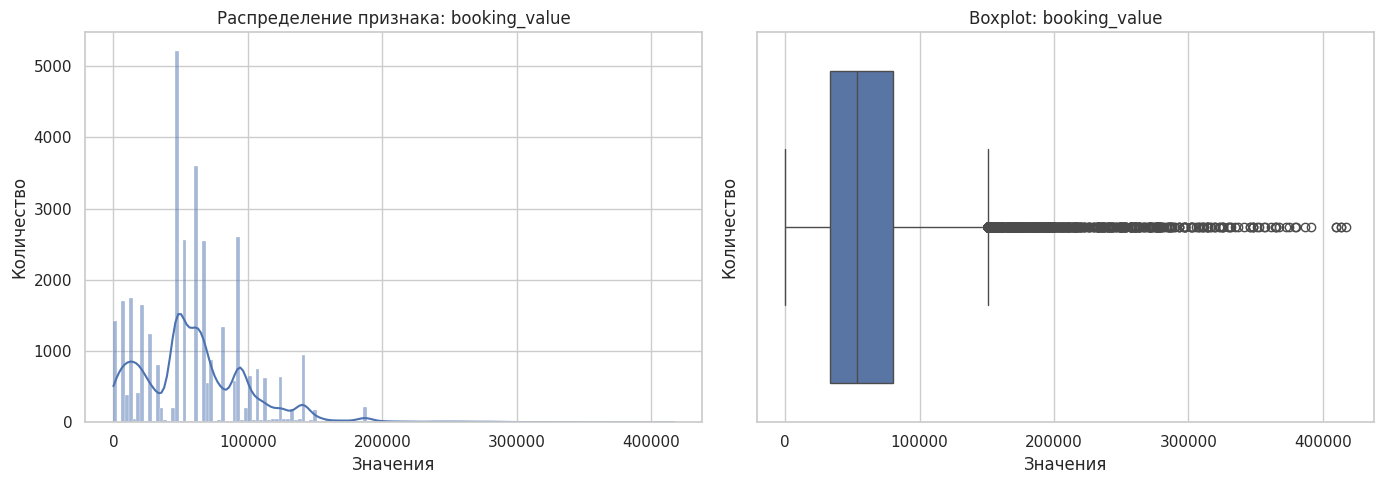

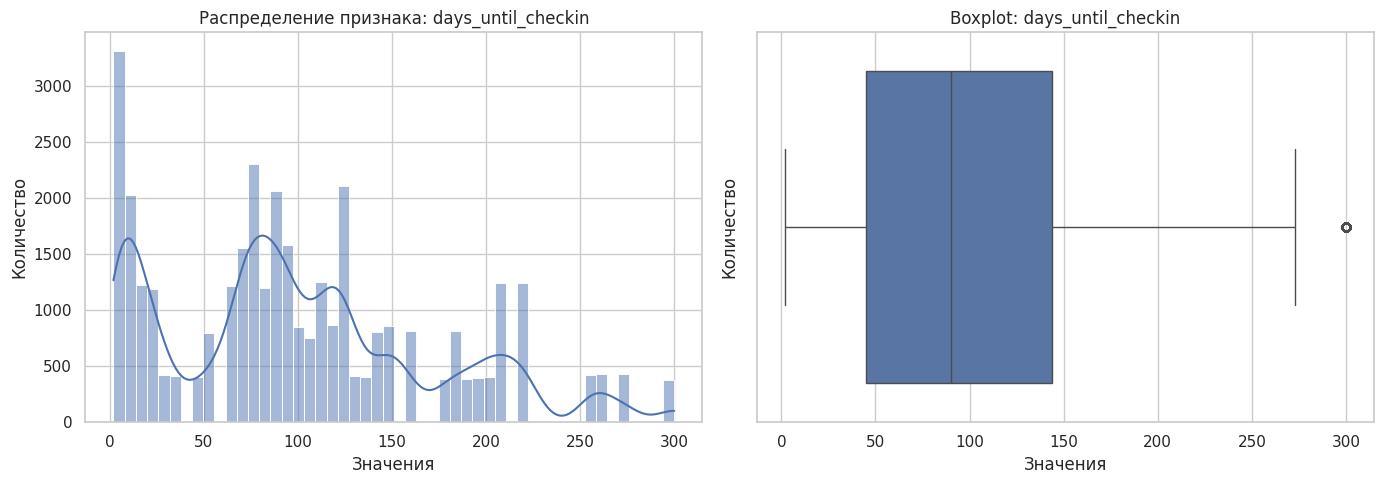

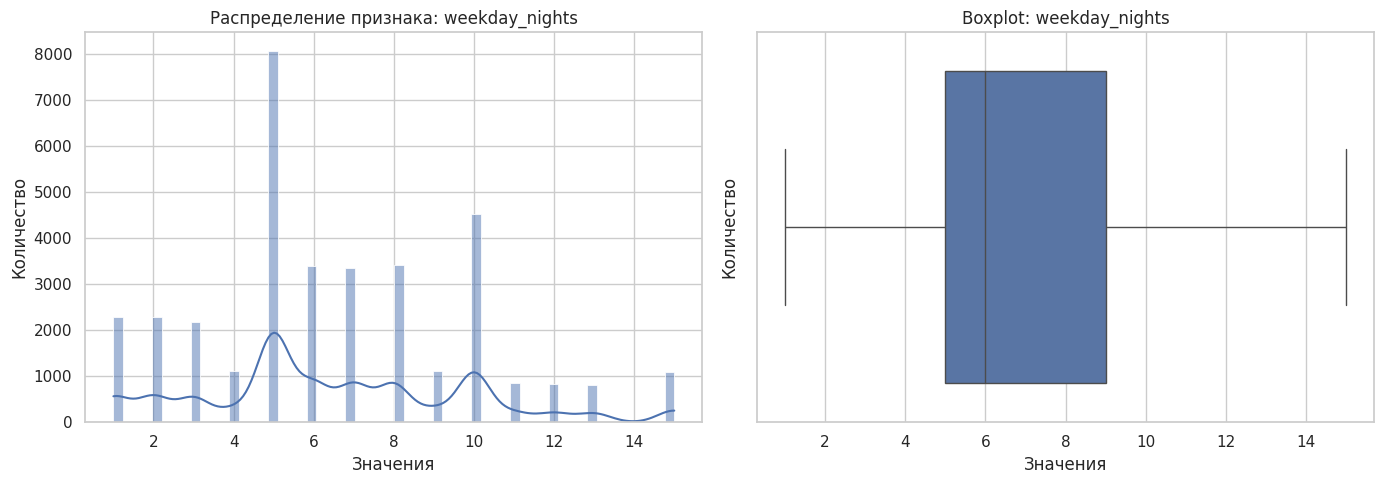

In [13]:
for col in num_cols:
    graphics_numerical(df_1, col)

In [14]:
zero_value = df_1["booking_value"].eq(0)

print("Нулевых:", zero_value.sum())
display(
    pd.crosstab(
        zero_value,
        df_1["booking_status"],
        margins=True,
        normalize="index",
    )
)

Нулевых: 1421


booking_status,нет_отказа,отказ_брони
booking_value,,
False,0.7125,0.2875
True,0.7108,0.2892
All,0.7124,0.2876


In [15]:
display(
    df_1.loc[zero_value, [
        "booking_value",
        "room_type",
        "adult_count",
        "child_count",
        "weekday_nights",
        "booking_status",
    ]].describe(include="all")
)

,booking_value,room_type,adult_count,child_count,weekday_nights,booking_status
count,1421.0000,1421,1421.0000,1421.0000,1421.0000,1421
unique,NaN,6,NaN,NaN,NaN,2
top,NaN,тип_1,NaN,NaN,NaN,нет_отказа
freq,NaN,1105,NaN,NaN,NaN,1010
mean,0.0000,NaN,14.0936,0.3434,6.6137,NaN
std,0.0000,NaN,49.4517,0.5780,3.2961,NaN
min,0.0000,NaN,1.0000,0.0000,1.0000,NaN
25%,0.0000,NaN,1.0000,0.0000,5.0000,NaN
50%,0.0000,NaN,2.0000,0.0000,6.0000,NaN
75%,0.0000,NaN,2.0000,1.0000,9.0000,NaN


In [16]:
display(
    df_1.nlargest(10, "adult_count")[
        ["booking_id", "adult_count", "child_count", "room_type", "booking_value"]
    ]
)

,booking_id,adult_count,child_count,room_type,booking_value
0,INN00000,300,0,тип_1,6700.0000
197,INN00197,300,0,тип_1,46900.0000
285,INN00285,300,0,тип_1,53600.0000
325,INN00325,300,1,тип_1,140700.0000
329,INN00329,300,0,тип_1,107200.0000
336,INN00336,300,0,тип_1,151300.0000
374,INN00374,300,0,тип_1,53600.0000
385,INN00385,300,1,тип_1,80100.0000
445,INN00445,300,1,тип_4,80400.0000
446,INN00446,300,1,тип_1,97900.0000


In [17]:
pd.crosstab(df_1["adult_count"], df_1["sales_channel"])

sales_channel,корпоративное_бронирование,онлайн_бронирование,офлайн_бронирование
adult_count,,,
1,4472,4248,4641
2,4291,4295,4516
3,2256,2295,2176
100,288,293,303
200,297,284,291
300,143,139,113


In [18]:
def input_processing(df):
    df["booking_value_missing"] = df["booking_value"].eq(0).astype("int8")
    df["booking_value"] = df["booking_value"].replace(0, np.nan)
    df["adult_count"] = df["adult_count"].replace({
    100: 1,
    200: 2,
    300: 3,
    })

    assert set(df["adult_count"]) <= {1, 2, 3}


In [19]:
input_processing(df_1)

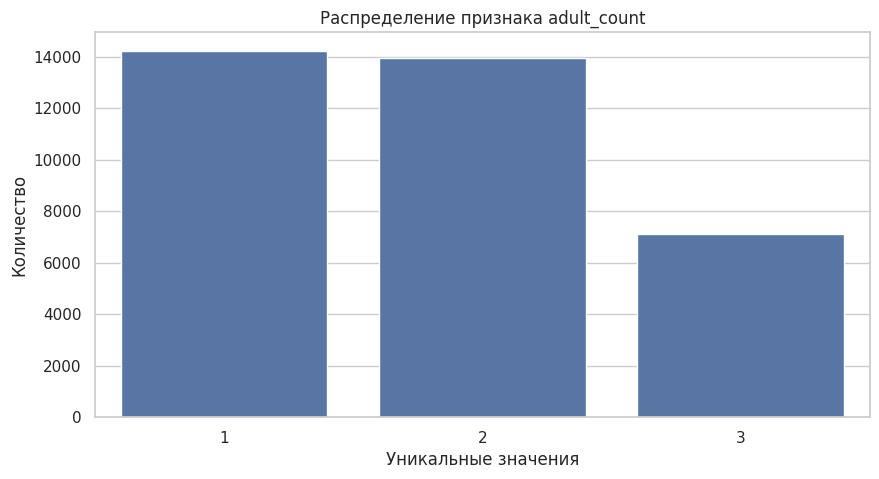

Распределение adult_count, количество и доля


,Количество,Доля
adult_count,,
1,14245,0.4031
2,13974,0.3954
3,7122,0.2015


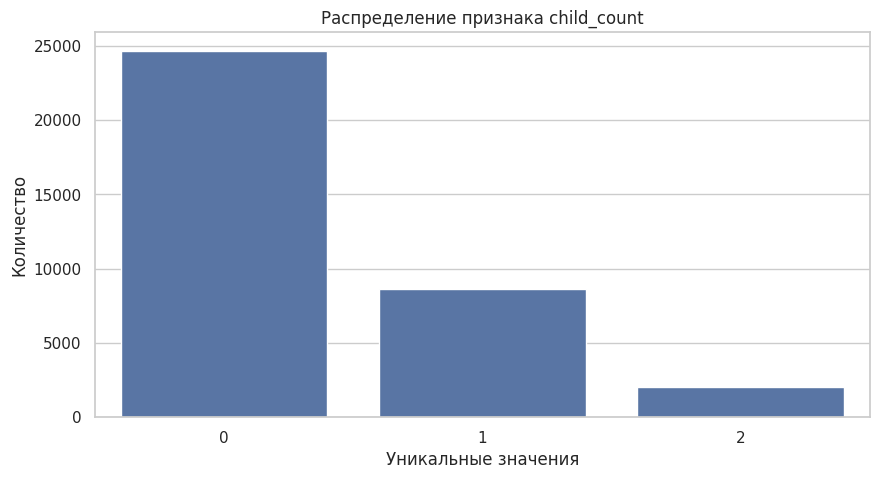

Распределение child_count, количество и доля


,Количество,Доля
child_count,,
0,24683,0.6984
1,8629,0.2442
2,2029,0.0574


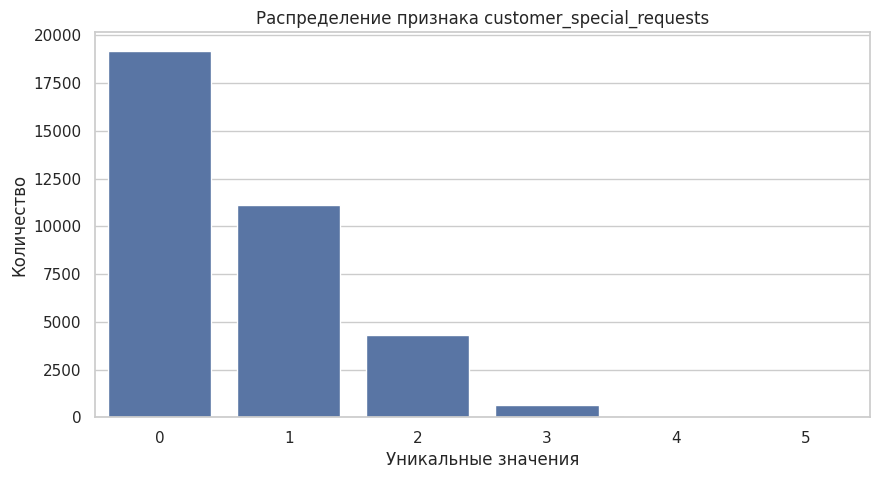

Распределение customer_special_requests, количество и доля


,Количество,Доля
customer_special_requests,,
0,19200,0.5433
1,11113,0.3145
2,4322,0.1223
3,625,0.0177
4,73,0.0021
5,8,0.0002


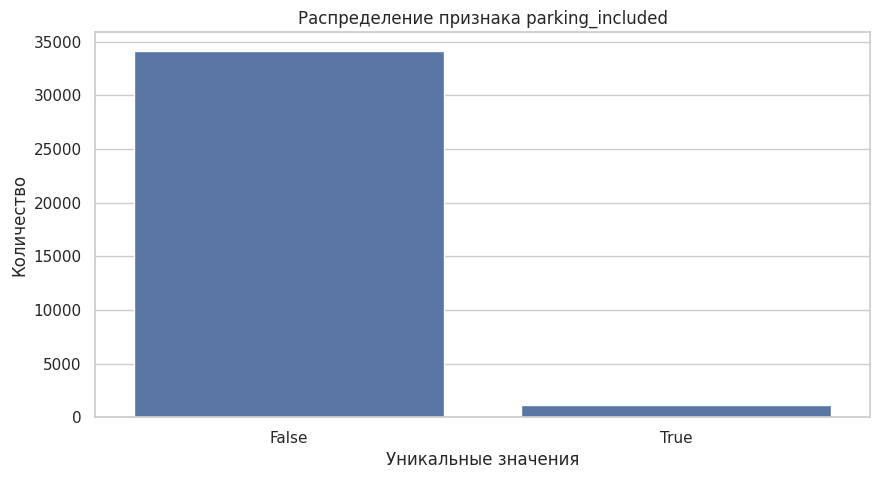

Распределение parking_included, количество и доля


,Количество,Доля
parking_included,,
False,34165,0.9667
True,1176,0.0333


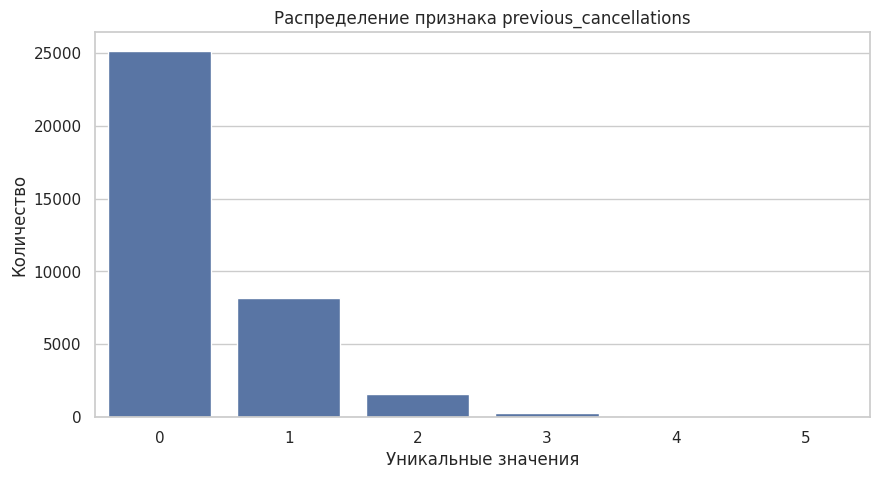

Распределение previous_cancellations, количество и доля


,Количество,Доля
previous_cancellations,,
0,25152,0.7117
1,8198,0.2320
2,1624,0.0460
3,304,0.0086
4,59,0.0017
5,4,0.0001


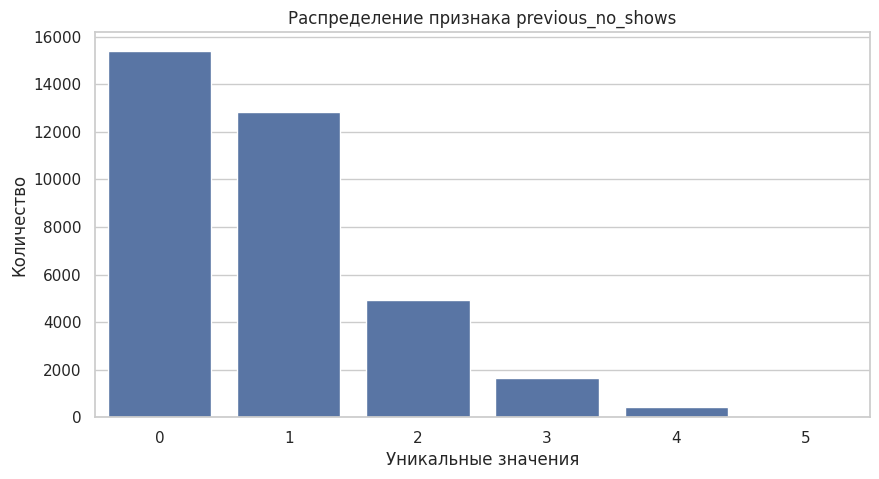

Распределение previous_no_shows, количество и доля


,Количество,Доля
previous_no_shows,,
0,15413,0.4361
1,12843,0.3634
2,4948,0.1400
3,1657,0.0469
4,440,0.0125
5,40,0.0011


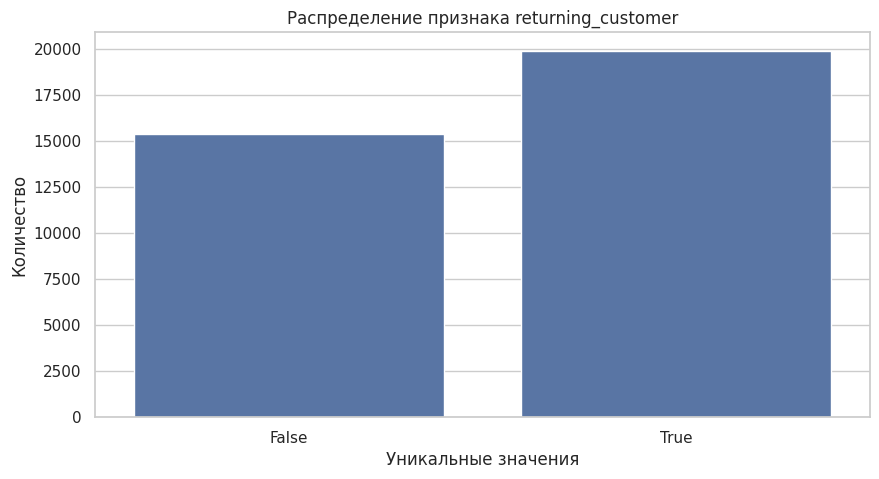

Распределение returning_customer, количество и доля


,Количество,Доля
returning_customer,,
True,19928,0.5639
False,15413,0.4361


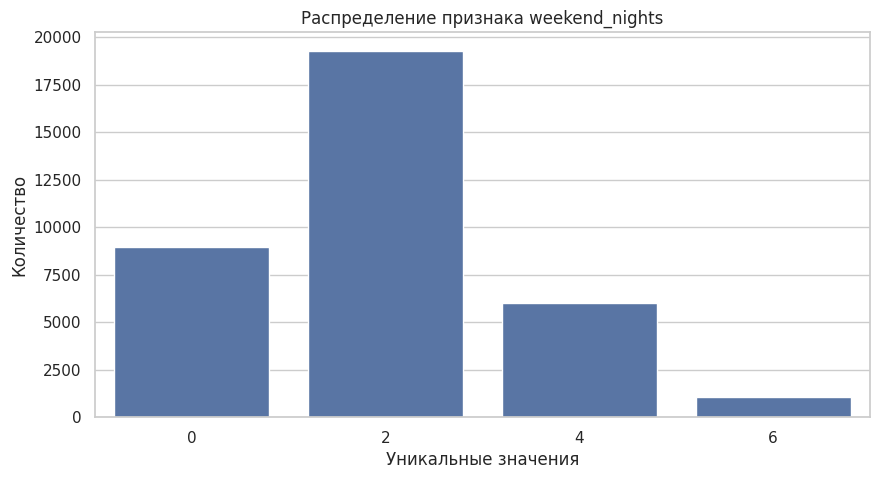

Распределение weekend_nights, количество и доля


,Количество,Доля
weekend_nights,,
2,19288,0.5458
0,8974,0.2539
4,5997,0.1697
6,1082,0.0306


In [20]:
for col in num_cat_cols:
    graphics_numerical_cat(df_1, col)

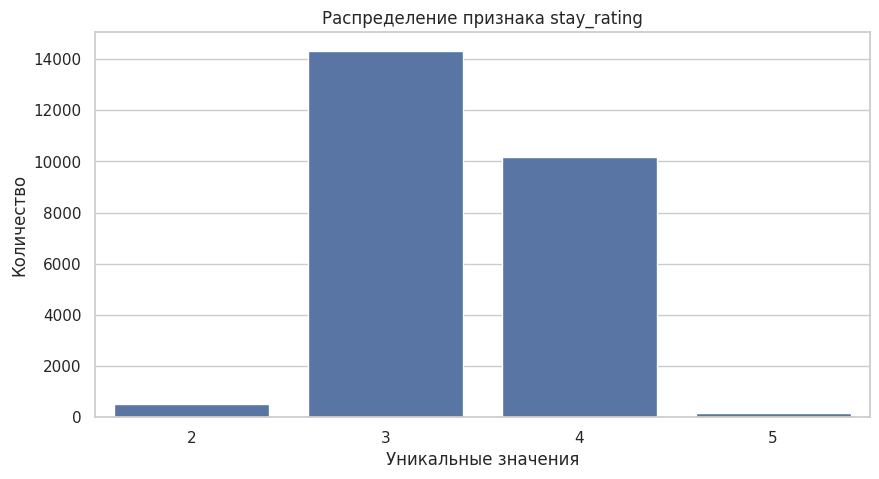

Распределение stay_rating, количество и доля


,Количество,Доля
stay_rating,,
3,14336,0.5694
4,10160,0.4035
2,523,0.0208
5,158,0.0063


In [21]:
for col in num_cat_cols_r:
    graphics_numerical_cat(df_2, col)

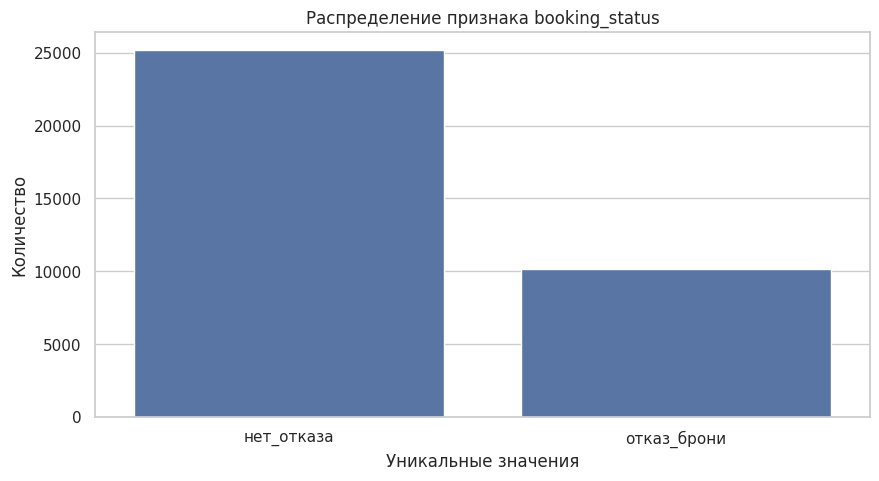

Распределение booking_status, количество и доля


,Количество,Доля
booking_status,,
нет_отказа,25177,0.7124
отказ_брони,10164,0.2876


In [22]:
graphics_numerical_cat(df_1, target)

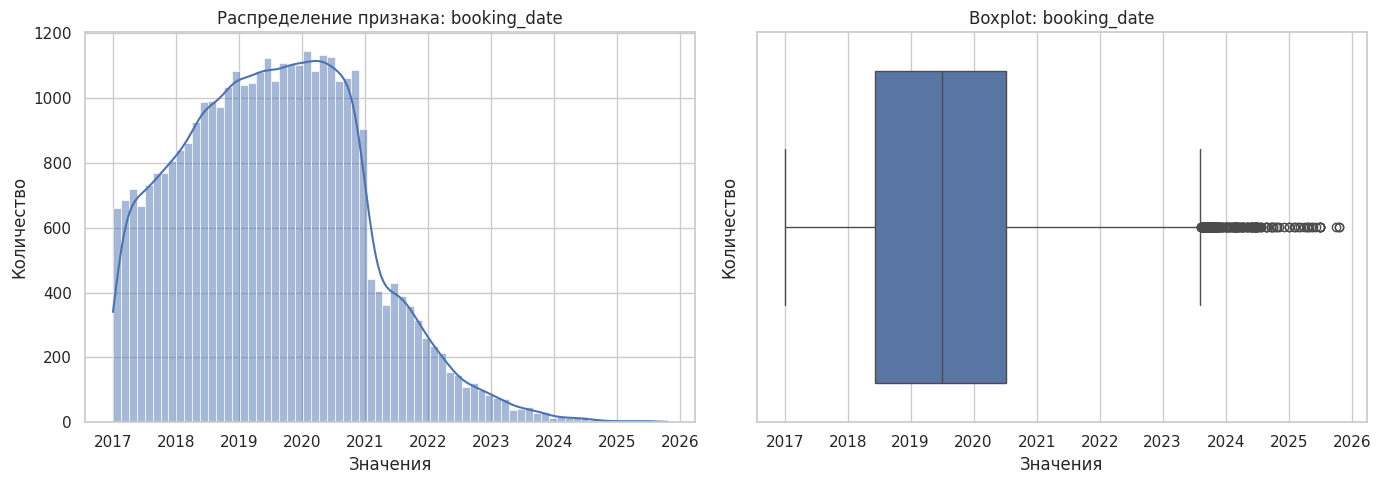

In [23]:
graphics_numerical(df_1, "booking_date")

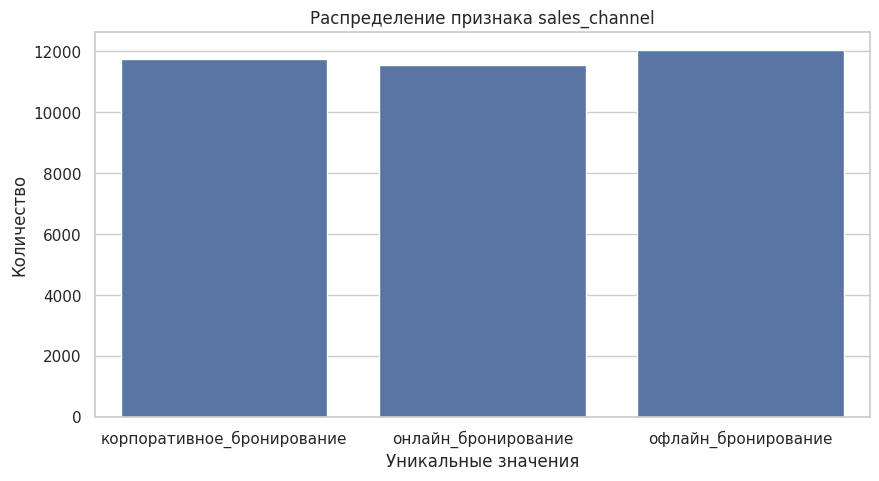

Распределение sales_channel, количество и доля


,Количество,Доля
sales_channel,,
офлайн_бронирование,12040,0.3407
корпоративное_бронирование,11747,0.3324
онлайн_бронирование,11554,0.3269


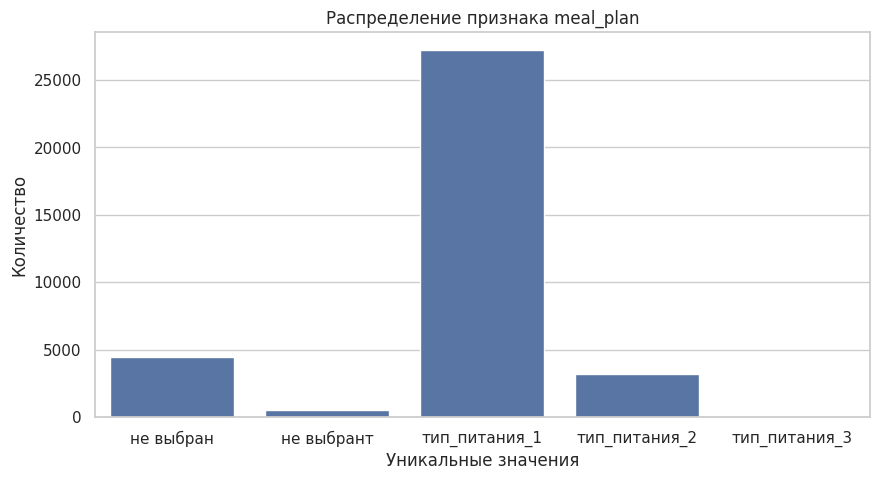

Распределение meal_plan, количество и доля


,Количество,Доля
meal_plan,,
тип_питания_1,27182,0.7691
не выбран,4426,0.1252
тип_питания_2,3219,0.0911
не выбрант,507,0.0143
тип_питания_3,7,0.0002


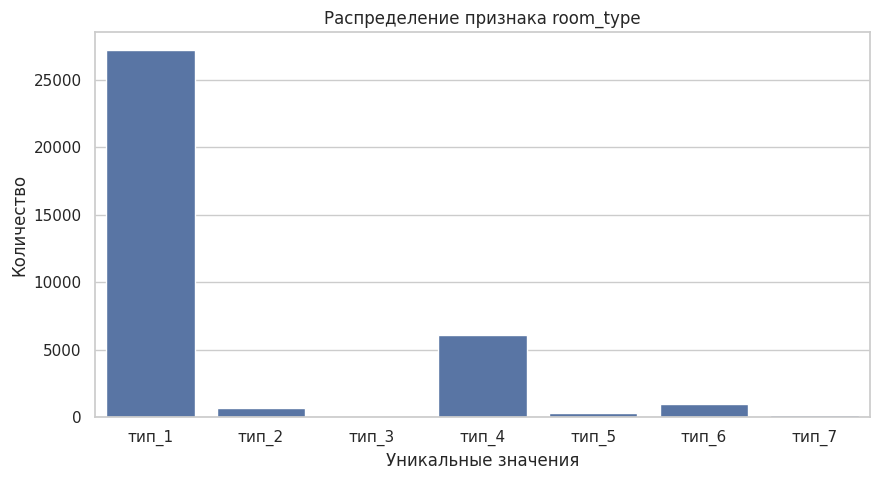

Распределение room_type, количество и доля


,Количество,Доля
room_type,,
тип_1,27197,0.7696
тип_4,6070,0.1718
тип_6,959,0.0271
тип_2,658,0.0186
тип_5,272,0.0077
тип_7,175,0.0050
тип_3,10,0.0003


In [24]:
for col in ["sales_channel", "meal_plan", "room_type"]:
    graphics_numerical_cat(df_1, col)

In [25]:
df_1["meal_plan"].value_counts()
df_1["meal_plan"] = df_1["meal_plan"].replace("не выбрант", "не выбран")

/tmp/ipykernel_2401477/1427324739.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_1["meal_plan"] = df_1["meal_plan"].replace("не выбрант", "не выбран")


In [26]:
df_1[df_1.duplicated(keep=False)].sort_values(by=["booking_id"]).head(10)

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,booking_value_missing
7,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0000,144,8,2,тип_питания_1,False,тип_4,0,0
33901,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0000,144,8,2,тип_питания_1,False,тип_4,0,0
31377,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0000,76,6,2,тип_питания_1,False,тип_6,1,0
13,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0000,76,6,2,тип_питания_1,False,тип_6,1,0
33239,INN00022,2020-03-02,корпоративное_бронирование,3,0,True,0,3,отказ_брони,33500.0000,77,5,0,тип_питания_1,False,тип_4,1,0
22,INN00022,2020-03-02,корпоративное_бронирование,3,0,True,0,3,отказ_брони,33500.0000,77,5,0,тип_питания_1,False,тип_4,1,0
27,INN00027,2020-08-21,корпоративное_бронирование,2,1,False,0,0,нет_отказа,80400.0000,150,10,2,не выбран,False,тип_4,0,0
33221,INN00027,2020-08-21,корпоративное_бронирование,2,1,False,0,0,нет_отказа,80400.0000,150,10,2,не выбран,False,тип_4,0,0
48,INN00048,2018-05-20,офлайн_бронирование,2,0,False,0,0,нет_отказа,67000.0000,11,8,2,не выбран,False,тип_4,2,0
32499,INN00048,2018-05-20,офлайн_бронирование,2,0,False,0,0,нет_отказа,67000.0000,11,8,2,не выбран,False,тип_4,2,0


In [27]:
df_1.duplicated().sum()

np.int64(4608)

In [28]:
print("Всего строк", len(df_1))
print("Дубликатов:", df_1.duplicated().sum())
df_1 = df_1.drop_duplicates().reset_index(drop=True)

print("Всего строк после удаления", len(df_1))
print("Дубликатов после удаления:", df_1.duplicated().sum())

Всего строк 35341
Дубликатов: 4608
Всего строк после удаления 30733
Дубликатов после удаления: 0


In [29]:
display(df_2[df_2.duplicated(keep=False)].sort_values(by=["booking_id"]))
df_2[df_2.duplicated(subset="booking_id")]


,customer_id,booking_id,review_date,stay_rating,review_text


,customer_id,booking_id,review_date,stay_rating,review_text
15664,C0258,INN00474,2017-12-18,3,"Неплохо. быстро заселили, но старые номера."
15909,C11963,INN22316,2020-11-14,4,Отличный отель! удобные подушки и матрасы.
15916,C6296,INN11807,2020-12-18,3,"Неплохо. комфортные номера, но проблемы с горя..."
17808,C13443,INN25023,2020-12-18,3,"Неплохо. вежливый персонал, но тесные номера."
18147,C13693,INN25485,2020-06-06,4,Отличный отель! разнообразное меню в ресторане.
...,...,...,...,...,...
25172,C3587,INN06721,2020-02-25,3,"Неплохо. своевременная уборка номеров, но нет ..."
25173,C7130,INN13369,2019-06-02,4,Отличный отель! качественные продукты на завтрак.
25174,C15588,INN29068,2020-03-19,3,"Неплохо. быстро заселили, но далеко до центра ..."
25175,C4596,INN08545,2019-03-26,5,Лучший отдых! Приеду ещё не раз. сервис выше в...


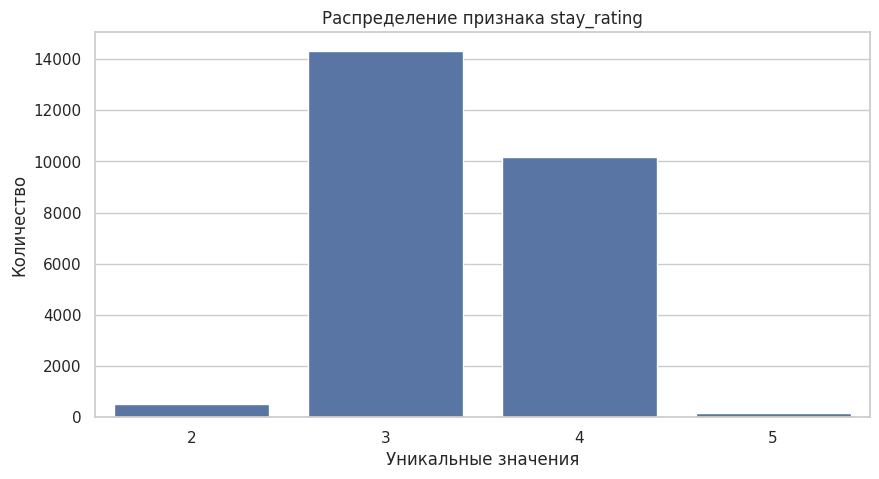

Распределение stay_rating, количество и доля


,Количество,Доля
stay_rating,,
3,14336,0.5694
4,10160,0.4035
2,523,0.0208
5,158,0.0063


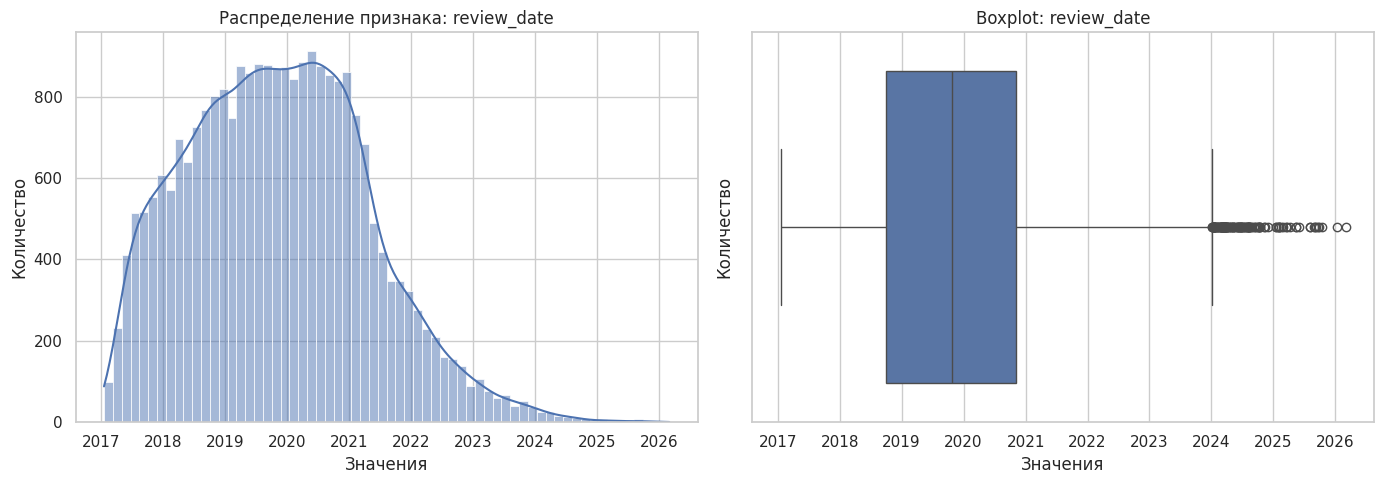

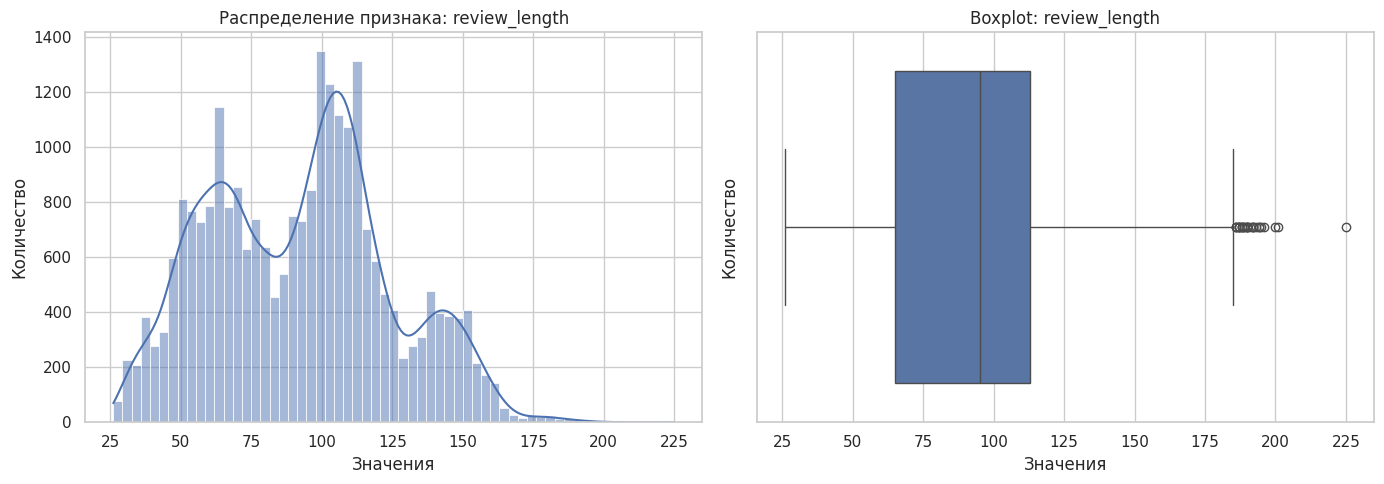

In [30]:
graphics_numerical_cat(df_2, "stay_rating")
graphics_numerical(df_2, "review_date")

df_2["review_length"] = df_2["review_text"].str.len()
graphics_numerical(df_2, "review_length")

In [31]:
stop_words = [
    "и", "в", "во", "что", "он", "на", "я", "с", "со", "как",
    "а", "то", "все", "она", "так", "его", "да", "ты", "к",
    "у", "же", "вы", "за", "бы", "по", "только", "ее", "мне",
    "было", "были", "был", "очень", "отель", "номере", "и", "от"
]

In [32]:
tokens = (
    df_2["review_text"]
    .dropna()
    .str.lower()
    .str.replace(r"[^\w\s-]", " ", regex=True)
    .str.split()
    .explode()
)

top_words = tokens.value_counts().head(40)
low_words = tokens.value_counts(ascending=True).head(40)
print(top_words)
low_words

review_text
в               18889
отель           14570
но              14356
неплохо         14336
отличный        10728
кондиционер      7189
от               7088
номере           5526
для              5242
не               5055
нет              4895
детей            4823
зоны             4550
ничего           4313
было             4308
скучно           4308
им               4308
номерах          4174
восторге         4045
дети             4045
игровой          4045
холодно          3982
одеяла           3696
выпрашивать      3696
пришлось         3696
второго          3696
тяжело           3686
справлялся       3686
на               3056
летом            2972
зимой            2827
есть             2682
спасал           2682
жары             2682
персонал         2617
хорошо           2550
отапливается     2550
номера           2368
и                1900
завтрак          1586
Name: count, dtype: int64


review_text
даже             4
зонах            4
отдохнуть        4
невозможно       4
общественных     4
недостаточное    4
мыться           5
приходилось      5
исправили        5
лифтах           5
холодной         5
жаловался        5
коридорах        5
полы             5
скудный          6
разочаровал      6
тот              6
бронировал       6
окна             6
фотографиям      6
ожидал           7
разочарован      7
находиться       7
неприятно        7
остывает         7
пахнет           7
обещанные        7
вызова           7
персонала        7
бронировании     7
бонусы           7
обслуживанием    7
сыростью         7
заверения        8
оборудования     8
фитнес-зале      8
пребывания       8
выключался       8
соблюдаются      8
подниматься      8
Name: count, dtype: int64

,token,count
0,недоволен,530
1,крайне,523
2,крайне недоволен,523
3,не,362
4,холодно,160
5,кондиционер,145
6,нет,142
7,номерах холодно,141
8,пришлось,141
9,пришлось выпрашивать,141


,token,count
0,отличный,10460
1,зоны,4242
2,игровой,4045
3,дети восторге,4045
4,восторге,4045
5,игровой зоны,4045
6,восторге игровой,4045
7,дети,4045
8,кондиционер,2906
9,кондиционер спасал,2682


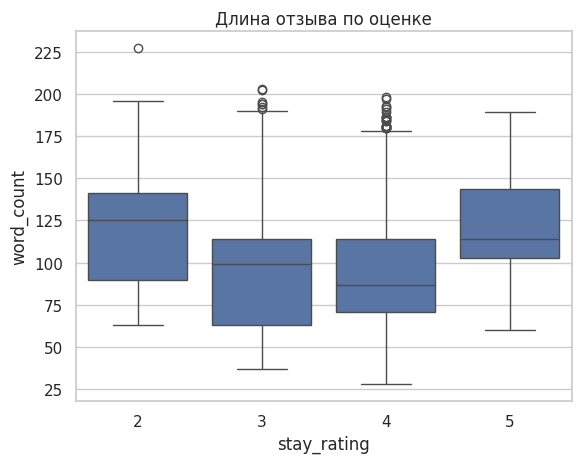

In [33]:
reviews_text = df_2[["stay_rating", "review_text"]].dropna().copy()
reviews_text["review_text"] = reviews_text["review_text"].str.lower()

bad_texts = reviews_text.loc[reviews_text["stay_rating"] <= 2, "review_text"]
good_texts = reviews_text.loc[reviews_text["stay_rating"] >= 4, "review_text"]

def top_ngrams(texts, ngram_range=(1, 2), top_n=30):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        min_df=2,
        stop_words=stop_words,
    )
    X = vectorizer.fit_transform(texts)

    return (
        pd.DataFrame({
            "token": vectorizer.get_feature_names_out(),
            "count": X.sum(axis=0).A1,
        })
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

top_bad = top_ngrams(bad_texts)
top_good = top_ngrams(good_texts)

display(top_bad)
display(top_good)

reviews_text["text_len"] = reviews_text["review_text"].str.len()
reviews_text["word_count"] = reviews_text["review_text"].str.split("").str.len()

reviews_text.groupby("stay_rating")[["text_len", "word_count"]].agg(["count", "mean", "median"])

sns.boxplot(data=reviews_text, x="stay_rating", y="word_count")
plt.title("Длина отзыва по оценке")
plt.show()

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable booking_date is large: 2445. Are you sure this is not an interval variable? Analysis for pairs of variables including booking_date can be slow.
  warnings.warn(


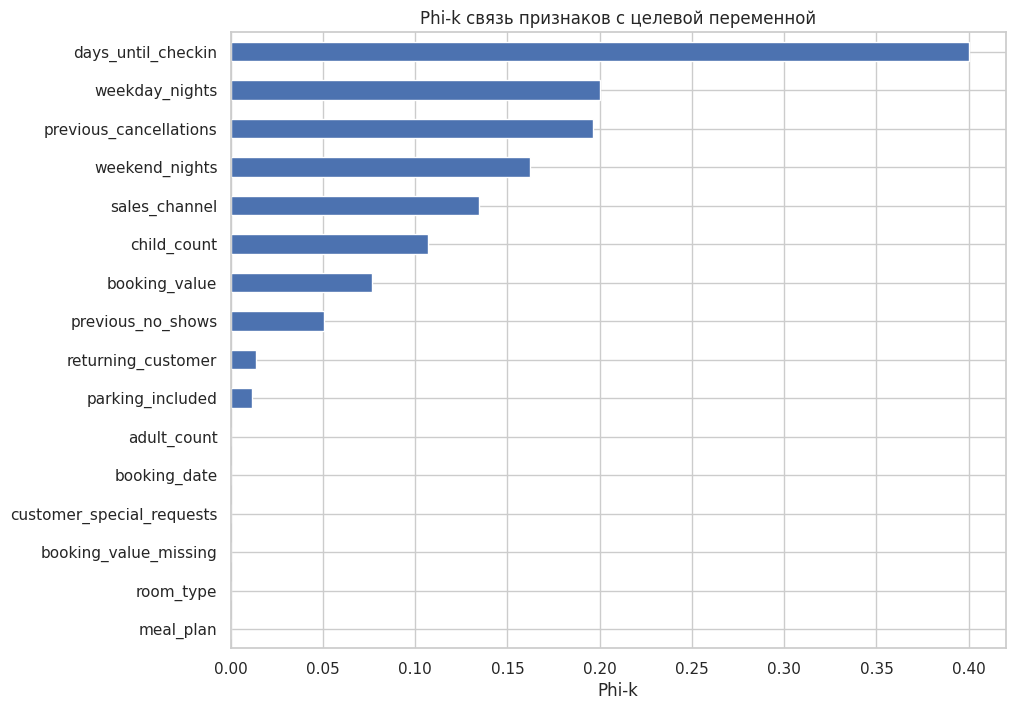

,phik_with_target
days_until_checkin,0.4000
weekday_nights,0.2003
previous_cancellations,0.1961
weekend_nights,0.1623
sales_channel,0.1344
child_count,0.1071
booking_value,0.0764
previous_no_shows,0.0508
returning_customer,0.0139
parking_included,0.0116


In [34]:
phik_data = df_1.drop(columns=["booking_id"]).copy()

interval_cols = [
    "booking_value",
    "days_until_checkin",
    "adult_count",
    "child_count",
    "weekday_nights",
    "weekend_nights",
    "previous_cancellations",
    "previous_no_shows",
    "customer_special_requests",
]

phik_corr = phik_data.phik_matrix(interval_cols=interval_cols)

target_phik = (
    phik_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

target_phik.sort_values().plot.barh(figsize=(10, 8))
plt.title("Phi-k связь признаков с целевой переменной")
plt.xlabel("Phi-k")
plt.show()

display(target_phik.to_frame("phik_with_target"))

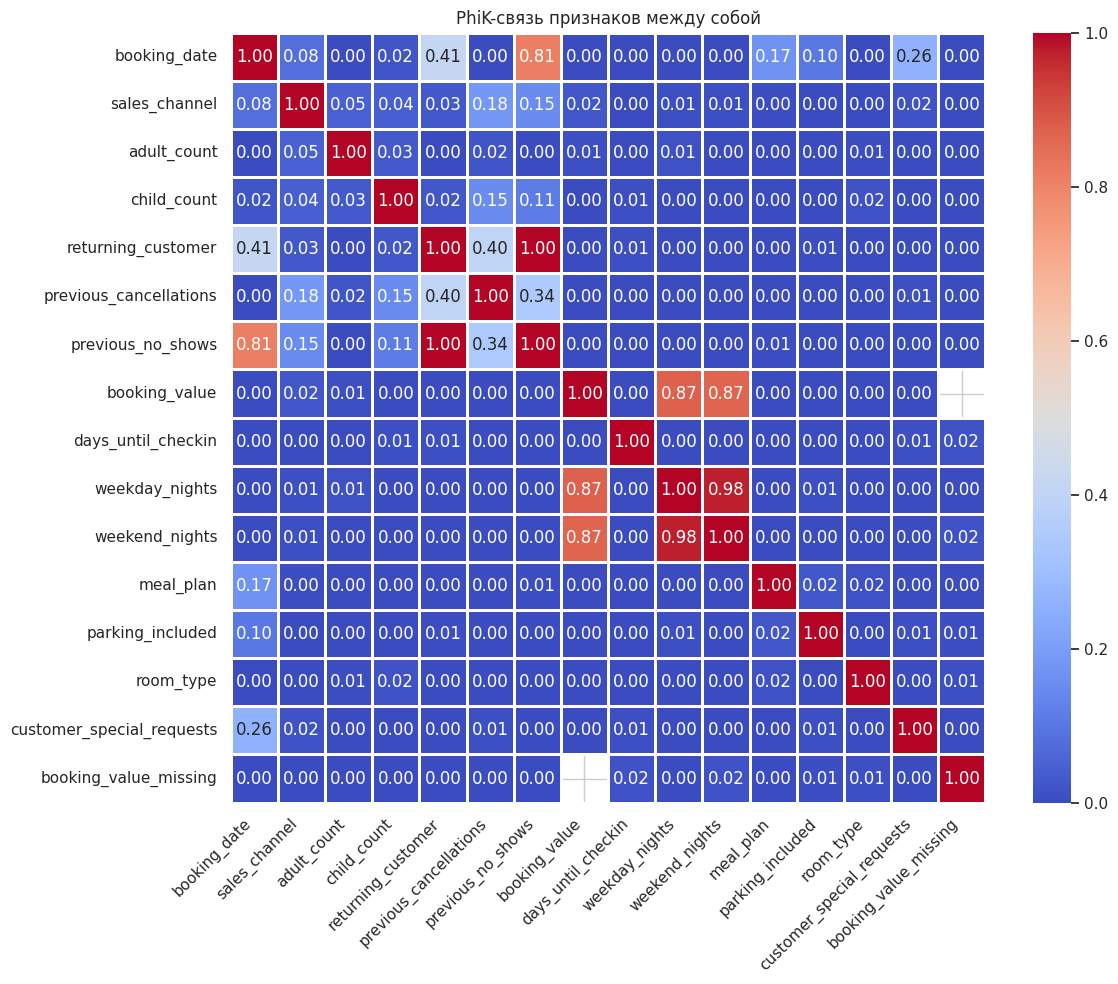

In [35]:
phik_features = phik_corr.drop(
    index=target,
    columns=target
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    phik_features,
    cmap="coolwarm",
    linewidths=1.0,
    cbar=True,
    annot=True,
    fmt=".2f"
)

plt.title("PhiK-связь признаков между собой")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Аналитический вывод по качеству данных

Данные пригодны для моделирования, но в них есть операционные дефекты, которые важны для бизнеса. Нулевые `booking_value` не похожи на реальные бесплатные брони, поэтому для финансовых расчётов это риск недооценки выручки и IR; такие значения нужно чинить в источнике данных, а не только импутировать в модели.

Ошибки в `adult_count` вида 100/200/300 выглядят как сбой кодирования количества гостей. Если такие ошибки остаются в CRM/PMS, они могут ломать не только ML, но и управленческие отчёты по загрузке, среднему чеку и составу гостей. Минимальная рекомендация для бизнеса — добавить валидации на стороне формы бронирования: число взрослых в разумном диапазоне, стоимость брони больше нуля или явная причина нулевой стоимости.


Очистка выполнена до моделирования только для явных ошибок и детерминированных исправлений: дубликаты, неверные категории, невозможные значения `adult_count`, нулевая стоимость как скрытый пропуск.


### Аналитический вывод по распределениям

Отмены составляют около 29%, то есть проблема достаточно крупная для экономического эффекта: это не редкая аномалия, а регулярная потеря потенциальной выручки. При такой доле отмен модель может быть полезна не только как алерт, но и как инструмент приоритизации работы менеджеров с рискованными бронями.

По отзывам видно, что числовой рейтинг почти не разделяет клиентов: 97% оценок находятся между 3 и 4. Для бизнеса это означает, что простая средняя оценка гостя малоинформативна. Гораздо ценнее текст: в нём повторяются конкретные причины недовольства — холод в номере, кондиционер, отсутствие удобств, скука для детей, завтрак, сервис. Эти темы можно использовать не только в ML, но и как список продуктовых проблем, влияющих на повторные бронирования и риск отмен.

Доминирование отдельных типов питания и номеров говорит, что большая часть потока стандартизирована. Поэтому основные управленческие действия лучше строить не вокруг редких категорий номера, а вокруг поведения клиента и параметров бронирования: канал продаж, горизонт до заезда, история отмен, состав гостей и длительность проживания.


### Проверка направлений гипотез

In [36]:
df_eda = df_1.assign(cancelled=df_1[target].eq("отказ_брони"))

for col in [
    "sales_channel",
    "returning_customer",
    "previous_cancellations",
    "customer_special_requests",
    "child_count",
]:
    display(
        df_eda.groupby(col, observed=True)["cancelled"]
        .agg(count="size", cancel_rate="mean")
        .sort_values("cancel_rate", ascending=False)
    )

,count,cancel_rate
sales_channel,,
онлайн_бронирование,10058,0.4151
офлайн_бронирование,10447,0.2834
корпоративное_бронирование,10228,0.1676


,count,cancel_rate
returning_customer,,
False,13408,0.2934
True,17325,0.2838


,count,cancel_rate
previous_cancellations,,
5,4,1.0000
3,268,0.5933
2,1420,0.4556
4,50,0.4000
1,7117,0.3531
0,21874,0.2518


,count,cancel_rate
customer_special_requests,,
5,7,0.4286
1,9657,0.2900
0,16716,0.2890
2,3742,0.2830
4,64,0.2812
3,547,0.2523


,count,cancel_rate
child_count,,
2,1725,0.4603
0,21496,0.3194
1,7512,0.1584


In [37]:
days_group = pd.qcut(df_1["days_until_checkin"], 4, duplicates="drop")
total_nights = df_1["weekday_nights"] + df_1["weekend_nights"]
nights_group = pd.cut(total_nights, bins=[0, 3, 7, 14, np.inf])

display(df_eda.groupby(days_group, observed=True)["cancelled"].agg(count="size", cancel_rate="mean"))
display(df_eda.groupby(nights_group, observed=True)["cancelled"].agg(count="size", cancel_rate="mean"))

,count,cancel_rate
days_until_checkin,,
"(1.999, 45.0]",7808,0.1501
"(45.0, 90.0]",7928,0.2597
"(90.0, 144.0]",7518,0.2533
"(144.0, 300.0]",7479,0.4967


,count,cancel_rate
"(0.0, 3.0]",5878,0.4238
"(3.0, 7.0]",7973,0.2274
"(7.0, 14.0]",13797,0.2666
"(14.0, inf]",3085,0.2814


### Аналитический вывод по факторам отмен

Главный управляемый риск — ранние бронирования: при горизонте более 144 дней отменяется почти половина броней. Для таких броней стоит вводить отдельный сценарий удержания: напоминания, подтверждение намерения ближе к дате заезда, мягкие предоплаты или персональные условия отмены.

Онлайн-канал даёт самый высокий риск отмены — 41,5% против 16,8% у корпоративного канала. это значит, что онлайн-брони должны получать более строгий скоринг риска и отдельные правила коммуникации. Корпоративный канал, наоборот, выглядит более устойчивым и может использоваться как якорь загрузки.

История отмен — сильный бизнес-признак: при 2-3 прошлых отменах риск резко растёт. Для таких клиентов оправданы более раннее подтверждение, предоплата или ограничение самых гибких тарифов.


### Объединение таблиц

In [38]:
df_hotel_with_client = df_1.merge(
        df_2[['booking_id', 'customer_id']].drop_duplicates(),
        on='booking_id',
        how='left'
    )


df_pairs = df_hotel_with_client.merge(
        df_2[['customer_id', 'booking_id', 'review_date', 'stay_rating', 'review_text']],
        on='customer_id'
    )

df_pairs = df_pairs[df_pairs['review_date'] < df_pairs['booking_date']].copy()

# Ближайший предыдущий отзыв для каждой брони
df_pairs = df_pairs.sort_values(['customer_id', 'booking_id_x', 'review_date'])
df_best_reviews = df_pairs.groupby(['customer_id', 'booking_id_x']).last().reset_index()
df = df_1.merge(
        df_best_reviews[['booking_id_x', 'stay_rating', 'review_text', 'review_date']],
        left_on='booking_id',
        right_on='booking_id_x',
        how='left'
    )

In [39]:
pd.crosstab(
    df["review_text"].notna(),
    df["booking_status"],
    margins=True,
    normalize="index"
)

booking_status,нет_отказа,отказ_брони
review_text,,
False,0.6050,0.3950
True,1.0000,0.0000
All,0.7120,0.2880


In [40]:
df[["booking_date", "review_date"]].sort_values(by="review_date").head(20)

,booking_date,review_date
350,2018-03-26,2017-01-21
26456,2017-08-19,2017-01-24
17876,2017-09-18,2017-01-30
20423,2018-03-09,2017-02-02
26439,2017-11-17,2017-02-04
22001,2017-09-19,2017-02-05
2948,2017-07-09,2017-02-06
24561,2018-05-23,2017-02-06
896,2018-01-03,2017-02-06
13010,2018-05-11,2017-02-07


In [41]:
df_isna = df_2[df_2["review_text"].isna()]
df_isna.head()

,customer_id,booking_id,review_date,stay_rating,review_text,review_length


### Объединение бронирований и отзывов

При объединении `hotel_bookings` и `hotel_reviews` возникает утечка целевой переменной.

Отзывы выбирались только с датой `review_date < booking_date`, поэтому временное условие соблюдено. Но в `hotel_bookings` нет `customer_id`, и идентификатор клиента восстанавливается через `hotel_reviews` по текущему `booking_id`.

Отзыв по текущему `booking_id` есть только у бронирований со статусом `нет_отказа`: клиент прожил в отеле и после этого мог оставить отзыв. У отменённых бронирований такого отзыва нет, поэтому для них не удаётся определить `customer_id` и найти прошлые отзывы.

В результате строки с найденным `review_text` относятся только к классу `нет_отказа`. Такой признак отражает факт состоявшегося проживания, то есть связан с целевой переменной.

В проде для новой брони текущего отзыва ещё не будет, поэтому таким способом нельзя будет восстановить `customer_id` и подтянуть прошлые отзывы. Из-за этого признаки отзывов (`review_text`, `stay_rating`, `review_date` и флаг наличия отзыва) исключаются из обучения модели (спойлер: нет). Для корректного использования отзывов нужен `customer_id` в таблице бронирований или отдельный справочник клиентов, доступный на момент бронирования.

In [42]:
df_vector = df.copy()

In [43]:
df_vector["review_text"].head()

0                                                  NaN
1    Неплохо. тихо и спокойно, но отсутствие фена в...
2    Неплохо. красивое оформление территории, но не...
3                                                  NaN
4                                                  NaN
Name: review_text, dtype: category
Categories (14153, object): ['Идеальный отель! Всё на высшем уровне. буду б..., 'Идеальный отель! Всё на высшем уровне. буду б..., 'Идеальный отель! Всё на высшем уровне. буду в..., 'Идеальный отель! Всё на высшем уровне. буду р..., ..., 'Превосходно! Рекомендую всем! сервис здесь — ..., 'Превосходно! Рекомендую всем! сервис здесь — ..., 'Превосходно! Рекомендую всем! уровень комфорт..., 'Превосходно! Рекомендую всем! чистота, уют, з...]

In [44]:
review_idx_5 = df_vector.index[df_vector["review_text"].notna()].tolist()[:5]
df_vector.loc[review_idx_5, ["booking_id", "review_text"]]

,booking_id,review_text
1,INN00001,"Неплохо. тихо и спокойно, но отсутствие фена в..."
2,INN00002,"Неплохо. красивое оформление территории, но не..."
5,INN00005,Отличный отель! качественная косметика в ванно...
6,INN00006,Отличный отель! приветливые официанты. уровень...
11,INN00011,"Неплохо. чистый бассейн, но холодно в номере з..."


In [45]:
def clean_text(text):
    if pd.isna(text):
        return text

    text = text.lower()
    text = re.sub(r"[\'\"«»“”,.!?\-–—;:]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    filtered_tokens = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(filtered_tokens)

In [46]:
before_after = df_vector.loc[
    review_idx_5,
    ["booking_id", "review_text"]
].copy()

before_after = before_after.rename(
    columns={"review_text": "review_text_before"}
)

df_vector_tmp = df_vector.copy()

df_vector_tmp["review_text"] = df_vector_tmp["review_text"].apply(clean_text)

before_after["review_text_after"] = df_vector_tmp.loc[
    review_idx_5,
    "review_text"
]

for i in review_idx_5:
    print("До")
    print("----------------------------------------------------------------------------------------------------------")
    print(before_after["review_text_before"][i])
    print("----------------------------------------------------------------------------------------------------------")
    print("После")
    print(before_after["review_text_after"][i])

До
----------------------------------------------------------------------------------------------------------
Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере
----------------------------------------------------------------------------------------------------------
После
неплохо тихо спокойно но отсутствие фена кондиционер не справлялся тяжело
До
----------------------------------------------------------------------------------------------------------
Неплохо. красивое оформление территории, но неработающий лифт.
----------------------------------------------------------------------------------------------------------
После
неплохо красивое оформление территории но неработающий лифт
До
----------------------------------------------------------------------------------------------------------
Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум
--------------------------------------------------------------

In [47]:
df_vector_apply = df.copy()
df_vector_apply["review_text"] = df["review_text"].apply(clean_text)

In [48]:
df = df_1
df.columns

Index(['booking_id', 'booking_date', 'sales_channel', 'adult_count',
       'child_count', 'returning_customer', 'previous_cancellations',
       'previous_no_shows', 'booking_status', 'booking_value',
       'days_until_checkin', 'weekday_nights', 'weekend_nights', 'meal_plan',
       'parking_included', 'room_type', 'customer_special_requests',
       'booking_value_missing'],
      dtype='object')

In [49]:
frames = [df, df_vector_apply]

for df_t in frames:
    df_t["booking_status"] = df_t["booking_status"].map({
        "нет_отказа": 0,
        "отказ_брони": 1,
    })

In [50]:
def make_session() -> requests.Session:
    s = requests.Session()
    s.headers.update({
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/120.0 Safari/537.36",
        "Accept-Language": "ru-RU,ru;q=0.9",
    })
    return s

session = make_session()
r = session.get("https://www.cbr.ru/currency_base/dynamics/?UniDbQuery.Posted=True&UniDbQuery.so=1&UniDbQuery.mode=1&UniDbQuery.date_req1=&UniDbQuery.date_req2=&UniDbQuery.VAL_NM_RQ=R01235&UniDbQuery.From=01.06.2016&UniDbQuery.To=25.06.2026", timeout=(3.05, 27))
tables = pd.read_html(r.text)

print(r.status_code, r.elapsed.total_seconds())
len(tables)

200 0.328267


/tmp/ipykernel_2401477/3462264622.py:13: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(r.text)


1

In [51]:
raw = tables[0]

usd = raw.iloc[2:].copy()
usd = usd[[0, 2]]
usd.columns = ["date", "usd_rub"]

usd["date"] = pd.to_datetime(usd["date"], dayfirst=True)
usd["usd_rub"] = (
    usd["usd_rub"]
    .astype(str)
    .str.replace(" ", "", regex=False)
    .astype(float) / 10000
)

usd = usd.sort_values("date").reset_index(drop=True)

print(len(usd))
usd.head()

2485


,date,usd_rub
0,2016-06-01,65.9962
1,2016-06-02,66.6156
2,2016-06-03,66.7491
3,2016-06-04,66.8529
4,2016-06-07,65.7894


In [52]:
usd_daily = (
    usd.set_index("date")
       .asfreq("D")
       .ffill()
       .bfill()
       .reset_index()
)

df = df.merge(
    usd_daily,
    how="left",
    left_on="booking_date",
    right_on="date",
).drop(columns=["date"])

df_vector_apply = df_vector_apply.merge(
    usd_daily,
    how="left",
    left_on="booking_date",
    right_on="date",
).drop(columns=["date"])

In [53]:
print(df["usd_rub"].isna().sum())
print(df_vector_apply["usd_rub"].isna().sum())

0
0


In [54]:
for df_n in [df, df_vector_apply]:
    df_n["checkin_date"] = (
        df_n["booking_date"]
        + pd.to_timedelta(df_n["days_until_checkin"], unit="D")
    )

    df_n["nights"] = (
        df_n["weekend_nights"]
        + df_n["weekday_nights"]
    )

In [55]:
def load_holidays_by_dates(dates, country_code="RU"):
    years = pd.Series(dates).dt.year.dropna().unique()
    rows = []

    for year in years:
        url = f"https://date.nager.at/api/v3/PublicHolidays/{int(year)}/{country_code}"
        data = requests.get(url, timeout=30).json()

        for h in data:
            rows.append({
                "holiday_date": h["date"],
                "holiday_name": h["localName"]
            })

    holidays = pd.DataFrame(rows)
    holidays["holiday_date"] = pd.to_datetime(holidays["holiday_date"])
    holidays = holidays.drop_duplicates(subset=["holiday_date"]).sort_values("holiday_date")
    return holidays.reset_index(drop=True)


def add_holiday_features(df, holiday_dates, window=7):
    holiday_dates = pd.DatetimeIndex(holiday_dates)

    df["is_checkin_holiday"] = df["checkin_date"].isin(holiday_dates).astype("int8")
    df["days_to_nearest_holiday"] = df["checkin_date"].apply(
        lambda d: np.abs((holiday_dates - d).days).min()
    )
    df["holiday_window"] = (df["days_to_nearest_holiday"] <= window).astype("int8")
    return df

In [56]:
holidays = load_holidays_by_dates(df["checkin_date"], country_code="RU")
df = add_holiday_features(df, holidays["holiday_date"], window=7)
df_vector_apply = add_holiday_features(df_vector_apply, holidays["holiday_date"], window=7)

In [57]:
df[["checkin_date", "is_checkin_holiday", "days_to_nearest_holiday", "holiday_window"]].head()

,checkin_date,is_checkin_holiday,days_to_nearest_holiday,holiday_window
0,2020-07-29,0,47,0
1,2021-10-04,0,31,0
2,2023-02-23,1,0,1
3,2017-07-11,0,29,0
4,2019-06-10,0,2,1


In [58]:
class AutoFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.median_price_per_room_ = {}
        self.channel_freq_ = {}
        self.global_price_per_night_median_ = 0

    def fit(self, X, y=None):
        safe_nights = X["nights"].replace(0, 1)
        price_per_night = X["booking_value"] / safe_nights

        self.global_price_per_night_median_ = float(price_per_night.median())
        self.median_price_per_room_ = (
            price_per_night
            .groupby(X["room_type"].astype(str))
            .median()
            .to_dict()
        )
        self.channel_freq_ = (
            X["sales_channel"]
            .astype(str)
            .value_counts(normalize=True)
            .to_dict()
        )

        return self

    def transform(self, X):
        X = X.copy()

        safe_nights = X["nights"].replace(0, np.nan)
        X["price_per_night"] = (X["booking_value"] / safe_nights).fillna(0)

        mapped_medians = (
            X["room_type"]
            .astype(str)
            .map(self.median_price_per_room_)
            .astype(float)
            .fillna(self.global_price_per_night_median_)
        )

        X["price_advantage_ratio"] = (
            X["price_per_night"] / mapped_medians.replace(0, 1)
        )

        X["channel_popularity"] = (
            X["sales_channel"]
            .astype(str)
            .map(self.channel_freq_)
            .astype(float)
            .fillna(0)
        )
        X["history_problem_count"] = (
            X["previous_cancellations"] + X["previous_no_shows"]
        )
        X["checkin_month"] = X["checkin_date"].dt.month
        X["checkin_dayofweek"] = X["checkin_date"].dt.dayofweek

        return X.drop(columns=["checkin_date"])

In [59]:
def calculate_metrics(y_true, y_pred, y_proba, cost_fp=7000, avg_rev=64500, lost_rev=64500, per_rebooking=45000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    total_success_before = (y_true == 0).sum()
    total_cancellations_before = (y_true == 1).sum()

    total_success_after = tn + fp + tp
    total_cancellations_after = fn

    ir_before = (
        total_success_before * avg_rev
        - total_cancellations_before * lost_rev
    )

    ir_after = (
        tp * per_rebooking
        + tn * avg_rev
        - fp * cost_fp
        - fn * lost_rev
    )

    share_cancellations_before = total_cancellations_before / len(y_true)
    share_cancellations_after = total_cancellations_after / len(y_true)

    occupancy_before = total_success_before / len(y_true)
    occupancy_after = total_success_after / len(y_true)

    return pd.DataFrame([{
        "IR_before": ir_before,
        "IR_after": ir_after,
        "IR_diff": ir_after - ir_before,
        "IR_share": ((ir_after - ir_before) / ir_before) * 100,
        "cancellation_share_before": share_cancellations_before,
        "cancellation_share_after": share_cancellations_after,
        "dynamic_cancellations": (
            (share_cancellations_before - share_cancellations_after)
            / share_cancellations_before
        ) * 100,
        "occupancy_before": occupancy_before,
        "occupancy_after": occupancy_after,
        "occupancy_dynamic": (
            (occupancy_before - occupancy_after)
            / occupancy_before
        ) * 100,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
    }])

In [60]:
df = df.sort_values("booking_date").reset_index(drop=True)
df = df.drop(columns=["booking_id", "booking_date"])

df_vector_apply = df_vector_apply.sort_values("booking_date").reset_index(drop=True)
df_vector_apply = df_vector_apply.drop(columns=["booking_id", "booking_date", "review_date", "booking_id_x"])

X = df.drop(columns=["booking_status"])
y = df["booking_status"]


X_vector = df_vector_apply.drop(columns=["booking_status"])
y_vector = df_vector_apply["booking_status"]

n = len(df)
train_end = int(n * 0.6)
calib_end = int(n * 0.8)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_calib = X.iloc[train_end:calib_end].copy()
y_calib = y.iloc[train_end:calib_end].copy()

X_test = X.iloc[calib_end:].copy()
y_test = y.iloc[calib_end:].copy()


X_train_vector = X_vector.iloc[:train_end].copy()
y_train_vector = y_vector.iloc[:train_end].copy()

X_calib_vector = X_vector.iloc[train_end:calib_end].copy()
y_calib_vector = y_vector.iloc[train_end:calib_end].copy()

X_test_vector = X_vector.iloc[calib_end:].copy()
y_test_vector = y_vector.iloc[calib_end:].copy()

In [61]:
tscv = TimeSeriesSplit(
    n_splits=3,
    test_size=2000
)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    X_tr = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[tr_idx]
    y_val = y_train.iloc[val_idx]

    print(f"Фолды {fold}:")
    print(X_tr.shape, X_val.shape)

Фолды 1:
(12439, 21) (2000, 21)
Фолды 2:
(14439, 21) (2000, 21)
Фолды 3:
(16439, 21) (2000, 21)


In [62]:
imputer_col = "booking_value"
vector_col = "review_text"

cat_cols = ["sales_channel", "meal_plan", "room_type"]

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_calib[col] = X_calib[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [63]:
preprocessor_vector = ColumnTransformer(
    transformers=[
        ("imputer", SimpleImputer(strategy="median"), [imputer_col]),
        ("vectorize", TfidfVectorizer(preprocessor=clean_text,
        stop_words=stop_words,
        ngram_range=(1, 2),
        min_df=2), vector_col)
])
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            selector(dtype_include=np.number),
        ),
        ("cat",OneHotEncoder(handle_unknown="ignore", sparse_output=False), selector(dtype_include=["object", "category", "bool"]),
        ),
    ],
    remainder="drop",
)
preprocessor = ColumnTransformer(
    transformers=[
        ("imputer", SimpleImputer(strategy="median"), [imputer_col]),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [64]:
dummy = DummyClassifier(strategy="stratified")

cat_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC",
    cat_features=tuple(cat_cols),
    verbose=0,
    random_seed=RANDOM_STATE,
)
lgb_base = LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1,
)

cat_feature_indices = [X_train.columns.get_loc(col) for col in cat_cols]

tabnet_base = TabNetClassifier(
    n_d=8,
    n_a=8,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-2,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(
        lr=1e-2,
        weight_decay=1e-4,
    ),

    mask_type="entmax",
    seed=RANDOM_STATE,
    verbose=1,
    device_name="cuda",
)

base_tabnet_feature = Pipeline(steps=[
    ("fe", AutoFeatureEngineer()),
    ("prep", nn_preprocessor),
    ("model", tabnet_base),
])

base_cat_feature = Pipeline(steps=[
    ("fe", AutoFeatureEngineer()),
    ("prep", preprocessor),
    ("model", cat_base),
])
base_lgb_feature = Pipeline(steps=[
    ("fe", AutoFeatureEngineer()),
    ("prep", preprocessor),
    ("model", lgb_base)
])


base_cat_vector = Pipeline(steps=[
    ("fe", AutoFeatureEngineer()),
    ("prep", preprocessor_vector),
    ("model", cat_base),
])
base_lgb_vector = Pipeline(steps=[
    ("fe", AutoFeatureEngineer()),
    ("prep", preprocessor_vector),
    ("model", lgb_base)
])


base_models = {
    "base_lgb_feature": base_lgb_feature,
    "base_cat_feature": base_cat_feature,
}

vector_models = {
    "base_cat_vector": base_cat_vector,
    "base_lgb_vector": base_lgb_vector,
}

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


### Аналитический вывод по выбору моделей

основная ставка сделана на CatBoost/LightGBM: они хорошо работают на табличных признаках, быстро обучаются и позволяют прозрачно сравнивать бизнес-метрики.

TabNet и AutoGluon использованы как проверка границ качества: TabNet показывает, даёт ли нейросетевой подход выигрыш, AutoGluon — насколько сильным может быть стэкинг.


In [65]:
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_calib)
y_dummy_proba = dummy.predict_proba(X_calib)[:, 1]

print("PR-AUC:", average_precision_score(y_calib, y_dummy_proba))

PR-AUC: 0.2992339037300734


In [66]:
tfidf = TfidfVectorizer(preprocessor=clean_text,
        stop_words=stop_words,
        ngram_range=(1, 2),
        min_df=2)
tfidf_matrix = tfidf.fit_transform(X_train_vector["review_text"].fillna(""))

X_train_no_text = X_train_vector.drop(columns=["review_text"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=X_train_vector.index,
)
X_train_vector = pd.concat(
    [X_train_no_text, tfidf_df],
    axis=1,
)


In [67]:
train_df_vector = X_train_vector.copy()
train_df_vector[target] = y_train_vector.values

train_df_base = X_train.copy()
train_df_base[target] = y_train.values

ag_display_cols = [
    "dataset_variant",
    "model",
    "score_val",
    "eval_metric",
    "fit_time",
    "pred_time_val",
]

autogluon взят как бейзлайн

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: AutoGluon baseline уже посчитан; повторный fit долгий и не нужен для финального запуска.
# Результаты сохранены и кратко описаны в markdown ниже.

# predictor_vector = TabularPredictor(
#     label=target,
#     problem_type="binary",
#     eval_metric="average_precision",
#     positive_class=1,
#     verbosity=0,
# )

# predictor_vector.fit(
#     train_data=train_df_vector,
#     presets="medium",
#     num_bag_folds=3,
#     time_limit=900,
#     num_cpus=4,
#     num_gpus=1,
#     memory_limit=4,
# )

# metrics_vector = predictor_vector.leaderboard(silent=True)
# metrics_vector["dataset_variant"] = "with_review_tfidf"

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: AutoGluon baseline уже посчитан; повторный fit долгий и не нужен для финального запуска.
# Результаты сохранены и кратко описаны в markdown ниже.

# predictor_base = TabularPredictor(
#     label=target,
#     problem_type="binary",
#     eval_metric="average_precision",
#     positive_class=1,
#     verbosity=0,
# )

# predictor_base.fit(
#     train_data=train_df_base,
#     presets="medium",
#     excluded_model_types=["NN_TORCH"],
#     num_bag_folds=3,
#     time_limit=900,
#     num_cpus=4,
#     num_gpus=1,
#     memory_limit=4,
# )

# metrics_base = predictor_base.leaderboard(silent=True)
# metrics_base["dataset_variant"] = "without_reviews"

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: AutoGluon baseline уже посчитан; повторный fit долгий и не нужен для финального запуска.
# Результаты сохранены и кратко описаны в markdown ниже.

# autogluon_metrics = pd.concat(
#     [metrics_base, metrics_vector],
#     ignore_index=True,
# )

# autogluon_metrics = (
#     autogluon_metrics
#     .sort_values("score_val", ascending=False)
#     .reset_index(drop=True)
# )

# display(autogluon_metrics[ag_display_cols])

,dataset_variant,model,score_val,eval_metric,fit_time,pred_time_val
0,with_review_tfidf,WeightedEnsemble_L2,0.7507,average_precision,48.9393,0.3693
1,with_review_tfidf,CatBoost_BAG_L1,0.7494,average_precision,10.2307,0.0473
2,with_review_tfidf,XGBoost_BAG_L1,0.7459,average_precision,11.6848,0.0821
3,with_review_tfidf,LightGBM_BAG_L1,0.7431,average_precision,1.9477,0.0476
4,with_review_tfidf,LightGBMXT_BAG_L1,0.7326,average_precision,2.3042,0.0668
5,with_review_tfidf,LightGBMLarge_BAG_L1,0.7322,average_precision,4.2547,0.0457
6,with_review_tfidf,NeuralNetFastAI_BAG_L1,0.7181,average_precision,24.6896,0.1906
7,with_review_tfidf,RandomForestEntr_BAG_L1,0.7057,average_precision,1.8343,1.7512
8,with_review_tfidf,RandomForestGini_BAG_L1,0.7019,average_precision,1.8439,1.7305
9,with_review_tfidf,ExtraTreesGini_BAG_L1,0.6890,average_precision,2.3747,1.8010


In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: AutoGluon baseline уже посчитан; повторный fit долгий и не нужен для финального запуска.
# Результаты сохранены и кратко описаны в markdown ниже.

# best_by_variant = (
#     autogluon_metrics
#     .sort_values("score_val", ascending=False)
#     .groupby("dataset_variant", as_index=False)
#     .first()
# )

# display(best_by_variant[ag_display_cols])

,dataset_variant,model,score_val,eval_metric,fit_time,pred_time_val
0,with_review_tfidf,WeightedEnsemble_L2,0.7507,average_precision,48.9393,0.3693
1,without_reviews,WeightedEnsemble_L2,0.6620,average_precision,8.9428,0.0420


### Аналитический вывод по AutoGluon baseline

AutoGluon показал важную для бизнеса картину: без отзывов лучший ансамбль даёт `average_precision = 0.6620`, а с TF-IDF по отзывам — `0.7507`. Прирост почти на 0.09 PR-AUC означает, что история клиентского опыта даёт больше полезного сигнала, чем перебор архитектур на одних табличных признаках.

Практический вывод: если цель — закрыть бизнес-метрики, первоочередная инвестиция - в правильную доступность клиентской истории на момент бронирования. AutoGluon полезен как бенча: ручная CatBoost-модель должна быть не хуже по бизнес-метрикам, но проще для контроля и внедрения.


In [72]:
def train_cv_pipelines(models, X, y, cv):
    scoring = {
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "pr_auc": "average_precision",
    }

    results = []

    for model_name, model in models.items():
        cv_result = cross_validate(
            estimator=model,
            X=X,
            y=y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            error_score="raise",
        )

        model_result = pd.DataFrame(cv_result)
        model_result["model"] = model_name
        model_result["fold"] = np.arange(1, len(model_result) + 1)

        results.append(model_result)

    cv_results = pd.concat(results, ignore_index=True)

    cv_summary = (
        cv_results
        .groupby("model", as_index=False)
        .agg(
            pr_auc_mean=("test_pr_auc", "mean"),
            pr_auc_std=("test_pr_auc", "std"),
            precision_mean=("test_precision", "mean"),
            precision_std=("test_precision", "std"),
            recall_mean=("test_recall", "mean"),
            recall_std=("test_recall", "std"),
            f1_mean=("test_f1", "mean"),
            f1_std=("test_f1", "std"),
            fit_time_mean=("fit_time", "mean"),
            fit_time_total=("fit_time", "sum"),
            score_time_mean=("score_time", "mean"),
        )
        .sort_values("pr_auc_mean", ascending=False)
    )

    return cv_results, cv_summary

In [73]:
cv_results_base, cv_summary_base = train_cv_pipelines(
    models=base_models,
    X=X_train,
    y=y_train,
    cv=tscv,
)

display(cv_results_base)
display(cv_summary_base)

,fit_time,score_time,test_precision,test_recall,test_f1,test_pr_auc,model,fold
0,0.0586,0.0134,0.6811,0.4480,0.5405,0.6406,base_lgb_feature,1
1,0.0496,0.0211,0.7155,0.4435,0.5476,0.6534,base_lgb_feature,2
2,0.0715,0.0231,0.6621,0.4098,0.5062,0.6267,base_lgb_feature,3
3,3.2823,0.0123,0.7097,0.4430,0.5455,0.6472,base_cat_feature,1
4,3.5090,0.0128,0.7188,0.4640,0.5640,0.6620,base_cat_feature,2
5,3.8367,0.0125,0.6771,0.3997,0.5027,0.6361,base_cat_feature,3


,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,fit_time_total,score_time_mean
0,base_cat_feature,0.6484,0.0130,0.7019,0.0219,0.4356,0.0328,0.5374,0.0315,3.5427,10.6280,0.0125
1,base_lgb_feature,0.6402,0.0133,0.6862,0.0270,0.4338,0.0209,0.5314,0.0221,0.0599,0.1797,0.0192


In [74]:
cv_results_vector, cv_summary_vector = train_cv_pipelines(
    models=base_models,
    X=X_train_vector,
    y=y_train_vector,
    cv=tscv,
)

display(cv_results_vector)
display(cv_summary_vector)

,fit_time,score_time,test_precision,test_recall,test_f1,test_pr_auc,model,fold
0,0.2527,0.0619,0.7092,0.5688,0.6313,0.7486,base_lgb_feature,1
1,0.3423,0.0542,0.7888,0.6010,0.6822,0.8057,base_lgb_feature,2
2,0.3217,0.0508,0.7588,0.5784,0.6565,0.7796,base_lgb_feature,3
3,7.3123,0.0737,0.7215,0.5738,0.6393,0.7530,base_cat_feature,1
4,7.6129,0.2412,0.7778,0.6233,0.6920,0.8090,base_cat_feature,2
5,8.5391,0.0743,0.7614,0.5649,0.6486,0.7804,base_cat_feature,3


,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,fit_time_total,score_time_mean
0,base_cat_feature,0.7808,0.0280,0.7536,0.0289,0.5873,0.0314,0.6600,0.0282,7.8214,23.4643,0.1297
1,base_lgb_feature,0.7779,0.0286,0.7523,0.0402,0.5827,0.0165,0.6567,0.0255,0.3056,0.9167,0.0556


In [75]:
##в документации не нашел эвал метрику
class PRAUC(Metric):
    def __init__(self):
        self._name = "pr_auc"
        self._maximize = True
    def __call__(self, y_true, y_score):
        return average_precision_score(y_true, y_score[:, 1])

In [76]:
def train_tabnet_cv(X, y, cv):
    results = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X), start=1):
        fit_start = time.perf_counter()

        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()

        fe = AutoFeatureEngineer()
        prep = clone(nn_preprocessor)
        model = clone(tabnet_base)

        X_tr_fe = fe.fit_transform(X_tr, y_tr)
        X_val_fe = fe.transform(X_val)

        X_tr_nn = np.asarray(prep.fit_transform(X_tr_fe, y_tr), dtype=np.float32)
        X_val_nn = np.asarray(prep.transform(X_val_fe), dtype=np.float32)

        model.fit(
            X_train=X_tr_nn,
            y_train=y_tr.values,
            eval_set=[(X_val_nn, y_val.values)],
            eval_name=["valid"],
            eval_metric=[PRAUC],
            max_epochs=300,
            patience=40,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False,
        )

        fit_time = time.perf_counter() - fit_start

        score_start = time.perf_counter()
        y_proba = model.predict_proba(X_val_nn)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)
        score_time = time.perf_counter() - score_start

        results.append({
            "fit_time": fit_time,
            "score_time": score_time,
            "test_precision": precision_score(y_val, y_pred, zero_division=0),
            "test_recall": recall_score(y_val, y_pred, zero_division=0),
            "test_f1": f1_score(y_val, y_pred, zero_division=0),
            "test_pr_auc": average_precision_score(y_val, y_proba),
            "model": "base_tabnet_feature",
            "fold": fold,
        })

    cv_results = pd.DataFrame(results)

    cv_summary = (
        cv_results
        .groupby("model", as_index=False)
        .agg(
            pr_auc_mean=("test_pr_auc", "mean"),
            pr_auc_std=("test_pr_auc", "std"),
            precision_mean=("test_precision", "mean"),
            precision_std=("test_precision", "std"),
            recall_mean=("test_recall", "mean"),
            recall_std=("test_recall", "std"),
            f1_mean=("test_f1", "mean"),
            f1_std=("test_f1", "std"),
            fit_time_mean=("fit_time", "mean"),
            fit_time_total=("fit_time", "sum"),
            score_time_mean=("score_time", "mean"),
        )
        .sort_values("pr_auc_mean", ascending=False)
    )

    return cv_results, cv_summary

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: TabNet CV уже посчитан; повторный GPU fit долгий и не является финальной моделью.
# Результаты сохранены и кратко описаны в markdown ниже.

# tabnet_cv_results, tabnet_cv_summary = train_tabnet_cv(
#     X=X_train,
#     y=y_train,
#     cv=tscv,
# )

# display(tabnet_cv_results)
# display(tabnet_cv_summary)

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.64596 | valid_pr_auc: 0.44016 |  0:00:00s
epoch 1  | loss: 0.60589 | valid_pr_auc: 0.4647  |  0:00:00s
epoch 2  | loss: 0.58842 | valid_pr_auc: 0.46467 |  0:00:00s
epoch 3  | loss: 0.57554 | valid_pr_auc: 0.46626 |  0:00:00s
epoch 4  | loss: 0.56646 | valid_pr_auc: 0.4647  |  0:00:00s
epoch 5  | loss: 0.55525 | valid_pr_auc: 0.47782 |  0:00:01s
epoch 6  | loss: 0.54625 | valid_pr_auc: 0.48245 |  0:00:01s
epoch 7  | loss: 0.54009 | valid_pr_auc: 0.49536 |  0:00:01s
epoch 8  | loss: 0.53823 | valid_pr_auc: 0.5075  |  0:00:01s
epoch 9  | loss: 0.53394 | valid_pr_auc: 0.50814 |  0:00:01s
epoch 10 | loss: 0.53062 | valid_pr_auc: 0.52473 |  0:00:01s
epoch 11 | loss: 0.53099 | valid_pr_auc: 0.51912 |  0:00:01s
epoch 12 | loss: 0.52626 | valid_pr_auc: 0.53501 |  0:00:01s
epoch 13 | loss: 0.52447 | valid_pr_auc: 0.5327  |  0:00:02s
epoch 14 | loss: 0.51984 | valid_pr_auc: 0.54878 |  0:00:02s
epoch 15 | loss: 0.51796 | valid_pr_auc: 0.55135 |  0:00:02s
epoch 16 | loss: 0.51778

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.64228 | valid_pr_auc: 0.40514 |  0:00:00s
epoch 1  | loss: 0.60644 | valid_pr_auc: 0.47425 |  0:00:00s
epoch 2  | loss: 0.58623 | valid_pr_auc: 0.47378 |  0:00:00s
epoch 3  | loss: 0.57541 | valid_pr_auc: 0.48593 |  0:00:00s
epoch 4  | loss: 0.56508 | valid_pr_auc: 0.49849 |  0:00:00s
epoch 5  | loss: 0.55662 | valid_pr_auc: 0.49682 |  0:00:00s
epoch 6  | loss: 0.54955 | valid_pr_auc: 0.5178  |  0:00:01s
epoch 7  | loss: 0.54673 | valid_pr_auc: 0.52424 |  0:00:01s
epoch 8  | loss: 0.54121 | valid_pr_auc: 0.52974 |  0:00:01s
epoch 9  | loss: 0.53902 | valid_pr_auc: 0.53683 |  0:00:01s
epoch 10 | loss: 0.5403  | valid_pr_auc: 0.53845 |  0:00:01s
epoch 11 | loss: 0.53774 | valid_pr_auc: 0.54207 |  0:00:02s
epoch 12 | loss: 0.5339  | valid_pr_auc: 0.55117 |  0:00:02s
epoch 13 | loss: 0.53227 | valid_pr_auc: 0.54462 |  0:00:02s
epoch 14 | loss: 0.52979 | valid_pr_auc: 0.54061 |  0:00:02s
epoch 15 | loss: 0.52782 | valid_pr_auc: 0.55966 |  0:00:02s
epoch 16 | loss: 0.52477

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.64649 | valid_pr_auc: 0.42549 |  0:00:00s
epoch 1  | loss: 0.60784 | valid_pr_auc: 0.4597  |  0:00:00s
epoch 2  | loss: 0.5891  | valid_pr_auc: 0.48271 |  0:00:00s
epoch 3  | loss: 0.57231 | valid_pr_auc: 0.51019 |  0:00:00s
epoch 4  | loss: 0.56044 | valid_pr_auc: 0.51008 |  0:00:00s
epoch 5  | loss: 0.55432 | valid_pr_auc: 0.52085 |  0:00:01s
epoch 6  | loss: 0.55041 | valid_pr_auc: 0.52885 |  0:00:01s
epoch 7  | loss: 0.5438  | valid_pr_auc: 0.53875 |  0:00:01s
epoch 8  | loss: 0.53918 | valid_pr_auc: 0.55113 |  0:00:01s
epoch 9  | loss: 0.53827 | valid_pr_auc: 0.55269 |  0:00:01s
epoch 10 | loss: 0.53581 | valid_pr_auc: 0.55704 |  0:00:02s
epoch 11 | loss: 0.53363 | valid_pr_auc: 0.53965 |  0:00:02s
epoch 12 | loss: 0.53157 | valid_pr_auc: 0.55029 |  0:00:02s
epoch 13 | loss: 0.53112 | valid_pr_auc: 0.56185 |  0:00:02s
epoch 14 | loss: 0.52783 | valid_pr_auc: 0.55244 |  0:00:02s
epoch 15 | loss: 0.5249  | valid_pr_auc: 0.55757 |  0:00:03s
epoch 16 | loss: 0.523  

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,fit_time,score_time,test_precision,test_recall,test_f1,test_pr_auc,model,fold
0,16.4842,0.0102,0.6708,0.4513,0.5396,0.6216,base_tabnet_feature,1
1,20.7394,0.0100,0.6845,0.4829,0.5663,0.6410,base_tabnet_feature,2
2,20.0267,0.0103,0.6854,0.4115,0.5142,0.6494,base_tabnet_feature,3


,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,fit_time_total,score_time_mean
0,base_tabnet_feature,0.6373,0.0142,0.6802,0.0082,0.4486,0.0358,0.5400,0.0260,19.0834,57.2503,0.0102


base_tabnet_feature	pr-auc mean 0.6243	std 0.0062	precision 0.6871	std 0.0047	 recall 0.3977	std 0.0304	f1 0.5033	std 0.0249	fit time 12.1604	 total 36.4813	scor time 0.0106

### Аналитический вывод по TabNet

TabNet не даёт достаточного основания усложнять решение. На обычных признаках качество ниже или сопоставимо с бустингами, а обучение требует отдельного preprocessing, `eval_set` и GPU-контроля. Даже на vector-ветке выигрыш не выглядит настолько большим, чтобы оправдать более сложную эксплуатацию.

Практический вывод для внедрения: для этой задачи выгоднее оставить CatBoost как основной production-кандидат. Он проще, быстрее, стабильнее в табличной задаче и лучше согласуется с требованием контролировать бизнес-метрики и порог принятия решений.


In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: TabNet CV уже посчитан; повторный GPU fit долгий и не является финальной моделью.
# Результаты сохранены и кратко описаны в markdown ниже.

# tabnet_cv_results_vector, tabnet_cv_summary_vector = train_tabnet_cv(
#     X=X_train_vector,
#     y=y_train_vector,
#     cv=tscv,
# )

# display(tabnet_cv_results_vector)
# display(tabnet_cv_summary_vector)

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.77529 | valid_pr_auc: 0.2968  |  0:00:00s
epoch 1  | loss: 0.67047 | valid_pr_auc: 0.39492 |  0:00:00s
epoch 2  | loss: 0.63973 | valid_pr_auc: 0.44245 |  0:00:00s
epoch 3  | loss: 0.63547 | valid_pr_auc: 0.45385 |  0:00:00s
epoch 4  | loss: 0.62461 | valid_pr_auc: 0.46385 |  0:00:01s
epoch 5  | loss: 0.62225 | valid_pr_auc: 0.46422 |  0:00:01s
epoch 6  | loss: 0.60824 | valid_pr_auc: 0.48365 |  0:00:01s
epoch 7  | loss: 0.61047 | valid_pr_auc: 0.44875 |  0:00:01s
epoch 8  | loss: 0.60539 | valid_pr_auc: 0.43902 |  0:00:01s
epoch 9  | loss: 0.59814 | valid_pr_auc: 0.4574  |  0:00:01s
epoch 10 | loss: 0.5902  | valid_pr_auc: 0.45185 |  0:00:02s
epoch 11 | loss: 0.57102 | valid_pr_auc: 0.52098 |  0:00:02s
epoch 12 | loss: 0.56708 | valid_pr_auc: 0.53137 |  0:00:02s
epoch 13 | loss: 0.54788 | valid_pr_auc: 0.57489 |  0:00:02s
epoch 14 | loss: 0.53021 | valid_pr_auc: 0.57783 |  0:00:02s
epoch 15 | loss: 0.51567 | valid_pr_auc: 0.58341 |  0:00:02s
epoch 16 | loss: 0.51306

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.75937 | valid_pr_auc: 0.24917 |  0:00:00s
epoch 1  | loss: 0.66397 | valid_pr_auc: 0.32432 |  0:00:00s
epoch 2  | loss: 0.64271 | valid_pr_auc: 0.4293  |  0:00:00s
epoch 3  | loss: 0.62613 | valid_pr_auc: 0.47592 |  0:00:00s
epoch 4  | loss: 0.61671 | valid_pr_auc: 0.49718 |  0:00:00s
epoch 5  | loss: 0.61022 | valid_pr_auc: 0.47357 |  0:00:01s
epoch 6  | loss: 0.60182 | valid_pr_auc: 0.53001 |  0:00:01s
epoch 7  | loss: 0.59168 | valid_pr_auc: 0.55545 |  0:00:01s
epoch 8  | loss: 0.57134 | valid_pr_auc: 0.60314 |  0:00:01s
epoch 9  | loss: 0.54117 | valid_pr_auc: 0.61214 |  0:00:01s
epoch 10 | loss: 0.53146 | valid_pr_auc: 0.64647 |  0:00:02s
epoch 11 | loss: 0.51437 | valid_pr_auc: 0.66519 |  0:00:02s
epoch 12 | loss: 0.49804 | valid_pr_auc: 0.6878  |  0:00:02s
epoch 13 | loss: 0.4956  | valid_pr_auc: 0.69445 |  0:00:02s
epoch 14 | loss: 0.49083 | valid_pr_auc: 0.695   |  0:00:03s
epoch 15 | loss: 0.48597 | valid_pr_auc: 0.70722 |  0:00:03s
epoch 16 | loss: 0.48347

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.75072 | valid_pr_auc: 0.31717 |  0:00:00s
epoch 1  | loss: 0.64937 | valid_pr_auc: 0.44307 |  0:00:00s
epoch 2  | loss: 0.63075 | valid_pr_auc: 0.48869 |  0:00:00s
epoch 3  | loss: 0.61709 | valid_pr_auc: 0.52778 |  0:00:00s
epoch 4  | loss: 0.60946 | valid_pr_auc: 0.49455 |  0:00:01s
epoch 5  | loss: 0.59839 | valid_pr_auc: 0.49716 |  0:00:01s
epoch 6  | loss: 0.58682 | valid_pr_auc: 0.46258 |  0:00:01s
epoch 7  | loss: 0.57873 | valid_pr_auc: 0.47462 |  0:00:01s
epoch 8  | loss: 0.56908 | valid_pr_auc: 0.51171 |  0:00:01s
epoch 9  | loss: 0.55787 | valid_pr_auc: 0.47831 |  0:00:02s
epoch 10 | loss: 0.54889 | valid_pr_auc: 0.48741 |  0:00:02s
epoch 11 | loss: 0.54045 | valid_pr_auc: 0.55382 |  0:00:02s
epoch 12 | loss: 0.5274  | valid_pr_auc: 0.61395 |  0:00:02s
epoch 13 | loss: 0.51367 | valid_pr_auc: 0.6122  |  0:00:03s
epoch 14 | loss: 0.50809 | valid_pr_auc: 0.522   |  0:00:03s
epoch 15 | loss: 0.4924  | valid_pr_auc: 0.58192 |  0:00:03s
epoch 16 | loss: 0.48766

/home/girev/ml/envs/urbanstay/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,fit_time,score_time,test_precision,test_recall,test_f1,test_pr_auc,model,fold
0,42.9146,0.0158,0.7532,0.4916,0.5949,0.7370,base_tabnet_feature,1
1,23.7220,0.0156,0.7538,0.5873,0.6603,0.7969,base_tabnet_feature,2
2,40.6892,0.0165,0.7535,0.5464,0.6334,0.7783,base_tabnet_feature,3


,model,pr_auc_mean,pr_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,fit_time_total,score_time_mean
0,base_tabnet_feature,0.7707,0.0307,0.7535,0.0003,0.5418,0.0480,0.6295,0.0328,35.7753,107.3258,0.0160


base_tabnet_feature	pr-auc 0.7707	std 0.0307	precision 0.7535	std 0.0003	recall 0.5418	std 0.0480	f1 0.6295	std 0.0328	fit time 35.1333	total 105.3998	scor time 0.0156

In [79]:
optuna_typing = pd.DataFrame()

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: Optuna уже отработала; лучшие параметры зафиксированы ниже вручную.
# Результаты сохранены и кратко описаны в markdown ниже.

# def objective_cat(trial):
#     params = {
#         "loss_function": "Logloss",
#         "eval_metric": "PRAUC",
#         "iterations": trial.suggest_int("iterations", 500, 2000),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
#         "depth": trial.suggest_int("depth", 3, 10),
#         "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
#         "auto_class_weights": trial.suggest_categorical(
#             "auto_class_weights",
#             [None, "Balanced", "SqrtBalanced"],
#         ),
#         "random_seed": RANDOM_STATE,
#         "verbose": 0,
#         "cat_features": tuple(cat_cols),
#     }

#     ir_scores = []

#     for tr_idx, val_idx in tscv.split(X_train):
#         X_tr = X_train.iloc[tr_idx].copy()
#         X_val = X_train.iloc[val_idx].copy()
#         y_tr = y_train.iloc[tr_idx].copy()
#         y_val = y_train.iloc[val_idx].copy()

#         pipe = Pipeline(steps=[
#             ("fe", AutoFeatureEngineer()),
#             ("prep", preprocessor),
#             ("model", CatBoostClassifier(**params)),
#         ])

#         pipe.fit(X_tr, y_tr)

#         y_proba = pipe.predict_proba(X_val)[:, 1]
#         y_pred = (y_proba >= 0.5).astype(int)

#         ir = calculate_metrics(
#             y_true=y_val,
#             y_pred=y_pred,
#             y_proba=y_proba,
#         )["IR_diff"].iloc[0]

#         ir_scores.append(ir)

#     return np.mean(ir_scores)


# study_cat = optuna.create_study(direction="maximize")
# study_cat.optimize(objective_cat, n_trials=30)

# metrics_optuna = pd.DataFrame({
#     "Модель": ["CatBoost"],
#     "Лучший IR": [study_cat.best_value],
#     "Лучшие параметры": [study_cat.best_params],
# })

# optuna_typing = pd.concat(
#     [optuna_typing, metrics_optuna],
#     ignore_index=True,
# )

# print("Best IR:", study_cat.best_value)
# print("Best params:", study_cat.best_params)


[I 2026-06-28 11:45:21,105] A new study created in memory with name: no-name-4823c2f2-a391-443d-8153-160e13032a1e
[I 2026-06-28 11:45:30,147] Trial 0 finished with value: 19479666.666666668 and parameters: {'iterations': 841, 'learning_rate': 0.08222447583600723, 'depth': 6, 'l2_leaf_reg': 8.872239171437913, 'auto_class_weights': None}. Best is trial 0 with value: 19479666.666666668.
[I 2026-06-28 11:45:38,993] Trial 1 finished with value: 22281166.666666668 and parameters: {'iterations': 932, 'learning_rate': 0.019533198731342793, 'depth': 5, 'l2_leaf_reg': 6.4567652794936645, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 1 with value: 22281166.666666668.
[I 2026-06-28 11:45:58,025] Trial 2 finished with value: 19975833.333333332 and parameters: {'iterations': 1503, 'learning_rate': 0.0684251123586591, 'depth': 7, 'l2_leaf_reg': 9.60265748640026, 'auto_class_weights': None}. Best is trial 1 with value: 22281166.666666668.
[I 2026-06-28 11:46:03,207] Trial 3 finished with value:

Best IR: 22299833.333333332
Best params: {'iterations': 1014, 'learning_rate': 0.010085951139929241, 'depth': 5, 'l2_leaf_reg': 6.562526141056889, 'auto_class_weights': 'SqrtBalanced'}


Best IR: 22414500.0
Best params: {'iterations': 517, 'learning_rate': 0.023138641064449808, 'depth': 7, 'l2_leaf_reg': 1.345702860783772, 'auto_class_weights': 'SqrtBalanced'}

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: Optuna уже отработала; лучшие параметры зафиксированы ниже вручную.
# Результаты сохранены и кратко описаны в markdown ниже.

# fig = plot_optimization_history(study_cat)
# fig.show()

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: Optuna уже отработала; лучшие параметры зафиксированы ниже вручную.
# Результаты сохранены и кратко описаны в markdown ниже.

# def objective_lgbm(trial):
#     params = {
#         "objective": "binary",
#         "metric": "average_precision",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "num_leaves": trial.suggest_int("num_leaves", 20, 256),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
#         "class_weight": trial.suggest_categorical(
#             "class_weight",
#             [None, "balanced"],
#         ),
#         "random_state": RANDOM_STATE,
#         "verbose": -1,
#         "n_jobs": -1,
#     }

#     ir_scores = []

#     for tr_idx, val_idx in tscv.split(X_train):
#         X_tr = X_train.iloc[tr_idx].copy()
#         X_val = X_train.iloc[val_idx].copy()
#         y_tr = y_train.iloc[tr_idx].copy()
#         y_val = y_train.iloc[val_idx].copy()

#         pipe = Pipeline(steps=[
#             ("fe", AutoFeatureEngineer()),
#             ("prep", preprocessor),
#             ("model", LGBMClassifier(**params)),
#         ])

#         pipe.fit(X_tr, y_tr)

#         y_proba = pipe.predict_proba(X_val)[:, 1]
#         y_pred = (y_proba >= 0.5).astype(int)

#         ir = calculate_metrics(
#             y_true=y_val,
#             y_pred=y_pred,
#             y_proba=y_proba,
#         )["IR_diff"].iloc[0]

#         ir_scores.append(ir)

#     return np.mean(ir_scores)



# study_lgbm = optuna.create_study(direction="maximize")
# study_lgbm.optimize(objective_lgbm, n_trials=30)

# metrics_optuna = pd.DataFrame({
#     "Модель": ["LightGBM"],
#     "Лучший IR": [study_lgbm.best_value],
#     "Лучшие параметры": [study_lgbm.best_params],
# })

# optuna_typing = pd.concat(
#     [optuna_typing, metrics_optuna],
#     ignore_index=True,
# )

# print("Best IR:", study_lgbm.best_value)
# print("Best params:", study_lgbm.best_params)

[I 2026-06-28 11:51:25,589] A new study created in memory with name: no-name-46d069d8-c441-4291-9d21-1b1b53ea13ca
[I 2026-06-28 11:51:26,903] Trial 0 finished with value: 17060000.0 and parameters: {'n_estimators': 1233, 'learning_rate': 0.09499929844942274, 'max_depth': 7, 'num_leaves': 48, 'min_child_samples': 87, 'reg_alpha': 0.0071676625206901325, 'reg_lambda': 4.158939267733366e-07, 'class_weight': None}. Best is trial 0 with value: 17060000.0.
[I 2026-06-28 11:51:28,008] Trial 1 finished with value: 17950666.666666668 and parameters: {'n_estimators': 907, 'learning_rate': 0.06527869936909128, 'max_depth': 6, 'num_leaves': 221, 'min_child_samples': 28, 'reg_alpha': 0.00028369839440306124, 'reg_lambda': 0.07903722551686003, 'class_weight': None}. Best is trial 1 with value: 17950666.666666668.
[I 2026-06-28 11:51:28,887] Trial 2 finished with value: 18898000.0 and parameters: {'n_estimators': 1976, 'learning_rate': 0.06861901570877164, 'max_depth': 3, 'num_leaves': 190, 'min_child_

Best IR: 19937666.666666668
Best params: {'n_estimators': 1852, 'learning_rate': 0.023056273869748706, 'max_depth': 3, 'num_leaves': 26, 'min_child_samples': 66, 'reg_alpha': 1.9600011161912257e-07, 'reg_lambda': 7.30871371525251e-07, 'class_weight': None}


### Аналитический вывод по Optuna

CatBoost после подбора даёт лучший средний IR, чем LightGBM: около 22.3 млн против 19.9 млн на CV. Поэтому финальный выбор стоит за CatBoost ё


Best IR: 20179333.333333332
Best params: {'n_estimators': 568, 'learning_rate': 0.011857409210207764, 'max_depth': 5, 'num_leaves': 25, 'min_child_samples': 79, 'reg_alpha': 6.638604079187591e-07, 'reg_lambda': 1.689051731556457e-06, 'class_weight': 'balanced'}

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: Optuna уже отработала; лучшие параметры зафиксированы ниже вручную.
# Результаты сохранены и кратко описаны в markdown ниже.

# fig = plot_optimization_history(study_lgbm)
# fig.show()

In [ ]:
# ОТКЛЮЧЕНО ДЛЯ ФИНАЛЬНОГО RUN ALL
# Причина: Optuna уже отработала; лучшие параметры зафиксированы ниже вручную.
# Результаты сохранены и кратко описаны в markdown ниже.

# optuna_typing

,Модель,Лучший IR,Лучшие параметры
0,CatBoost,22299833.3333,"{'iterations': 1014, 'learning_rate': 0.010085..."
1,LightGBM,19937666.6667,"{'n_estimators': 1852, 'learning_rate': 0.0230..."


In [87]:
best_params = {'iterations': 517,
               'learning_rate': 0.023138641064449808,
               'depth': 7,
               'l2_leaf_reg': 1.345702860783772,
               'auto_class_weights': 'SqrtBalanced'
              }

In [88]:
cat_params = {
    **best_params,
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "cat_features": tuple(cat_cols),
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}
pipe = Pipeline(steps=[
            ("fe", AutoFeatureEngineer()),
            ("prep", preprocessor),
            ("model", CatBoostClassifier(**cat_params)),
        ])
pipe.fit(X_train, y_train)

,steps,"[('fe', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [89]:
X_calib.shape

(6147, 21)

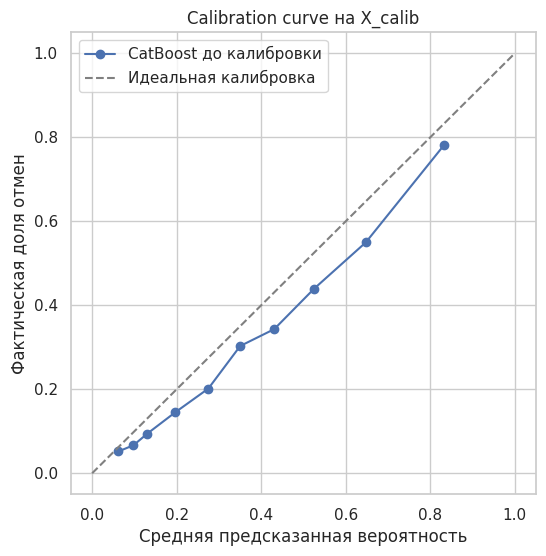

In [91]:
y_calib_proba_raw = pipe.predict_proba(X_calib)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_calib,
    y_calib_proba_raw,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="CatBoost до калибровки")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеальная калибровка")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля отмен")
plt.title("Calibration curve на X_calib")
plt.legend()
plt.grid(True)
plt.show()

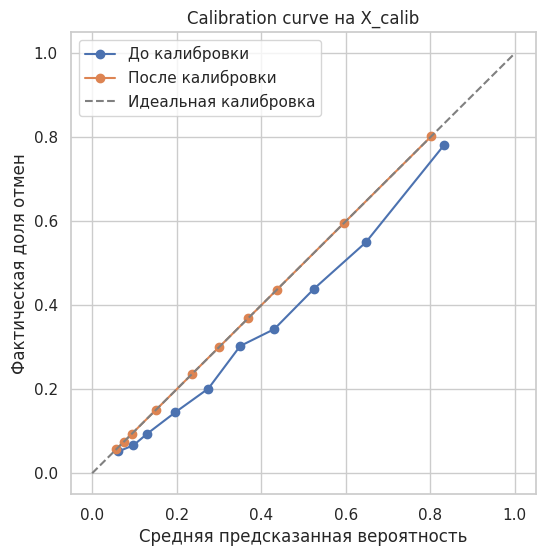

In [95]:
calibrated_cat = CalibratedClassifierCV(
        estimator=FrozenEstimator(pipe),
        method="isotonic",
    )
calibrated_cat.fit(X_calib, y_calib)

y_calib_proba_calibrated = calibrated_cat.predict_proba(X_calib)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(
    y_calib,
    y_calib_proba_calibrated,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="До калибровки")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="После калибровки")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеальная калибровка")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля отмен")
plt.title("Calibration curve на X_calib")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
y_calib_proba = calibrated_cat.predict_proba(X_calib)[:, 1]

threshold_results = []

for threshold in np.linspace(0.01, 0.99, 99):
    y_calib_pred = (y_calib_proba >= threshold).astype(int)

    metrics = calculate_metrics(
        y_true=y_calib,
        y_pred=y_calib_pred,
        y_proba=y_calib_proba,
    )

    row = metrics.iloc[0].to_dict()
    row["threshold"] = threshold
    threshold_results.append(row)

threshold_results = pd.DataFrame(threshold_results)

best_threshold_row = (
    threshold_results
    .sort_values("IR_diff", ascending=False)
    .iloc[0]
)

best_threshold = best_threshold_row["threshold"]

display(best_threshold_row.to_frame().T)
print(f"Лучший порог по IR на calib: {best_threshold:.2f}")

,IR_before,IR_after,IR_diff,IR_share,cancellation_share_before,cancellation_share_after,dynamic_cancellations,occupancy_before,occupancy_after,occupancy_dynamic,precision,recall,f1,pr_auc,threshold
34,160411500.0000,226556000.0000,66144500.0000,41.2343,0.2977,0.1085,63.5519,0.7023,0.8915,-26.9400,0.5760,0.6355,0.6043,0.6384,0.3500


Лучший порог по IR на calib: 0.35


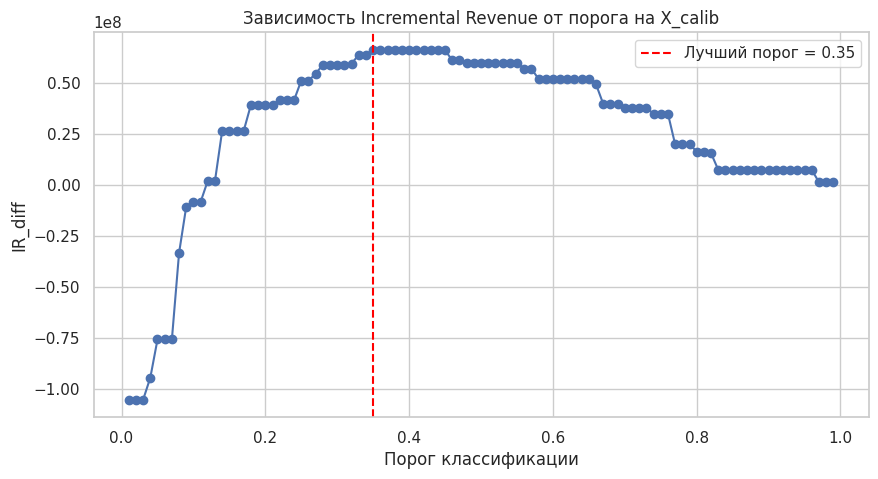

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(
    threshold_results["threshold"],
    threshold_results["IR_diff"],
    marker="o",
)
plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Лучший порог = {best_threshold:.2f}",
)
plt.xlabel("Порог классификации")
plt.ylabel("IR_diff")
plt.title("Зависимость Incremental Revenue от порога на X_calib")
plt.legend()
plt.grid(True)
plt.show()

### Аналитический вывод по порогу классификации

Порог подбирается по IR, потому что цена ошибок несимметрична. Пропущенная отмена — это потерянная выручка, ложное срабатывание — лишнее вмешательство в бронь, но не всегда потеря продажи. Поэтому оптимальный бизнес-порог может отличаться от 0.5 и от порога максимального F1.

Для модели без отзывов лучший порог на calib даёт сильное снижение отмен, но на test всё ещё не закрывает IR. Это показывает, что проблема не только в выборе порога: модели не хватает информации о клиенте.


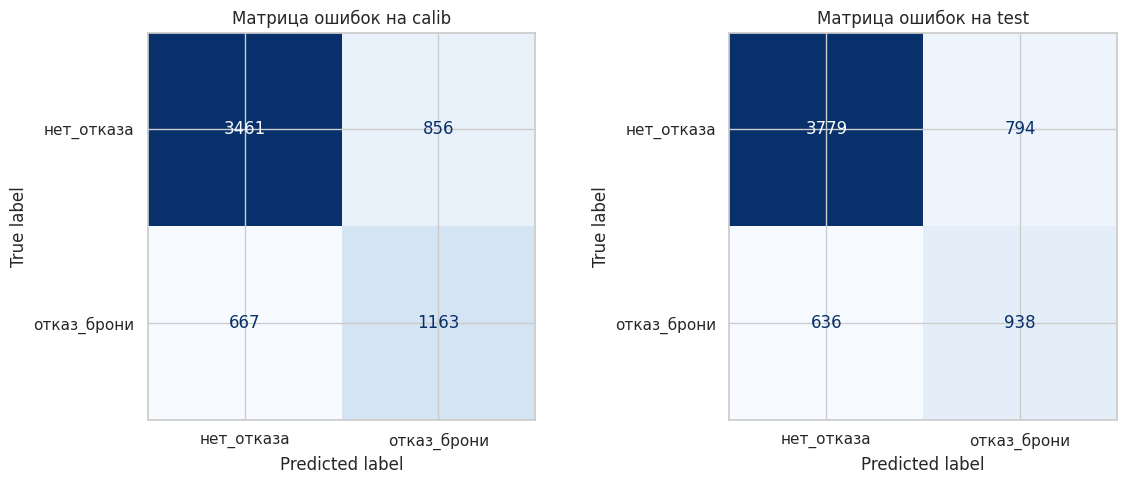

,dataset,IR_before,IR_after,IR_diff,IR_share,cancellation_share_before,cancellation_share_after,occupancy_before,occupancy_after,precision,recall,f1,pr_auc
0,calib,160411500,226556000,66144500,41.2343,0.2977,0.1085,0.7023,0.8915,0.5760,0.6355,0.6043,0.6384
1,test,193435500,239375500,45940000,23.7495,0.2561,0.1035,0.7439,0.8965,0.5416,0.5959,0.5675,0.6036


In [100]:
y_calib_proba_final = calibrated_cat.predict_proba(X_calib)[:, 1]
y_calib_pred_final = (y_calib_proba_final >= best_threshold).astype(int)

y_test_proba_final = calibrated_cat.predict_proba(X_test)[:, 1]
y_test_pred_final = (y_test_proba_final >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_calib,
    y_calib_pred_final,
    display_labels=["нет_отказа", "отказ_брони"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Матрица ошибок на calib")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_final,
    display_labels=["нет_отказа", "отказ_брони"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Матрица ошибок на test")

plt.tight_layout()
plt.show()

calib_metrics = calculate_metrics(
    y_true=y_calib,
    y_pred=y_calib_pred_final,
    y_proba=y_calib_proba_final,
)

test_metrics = calculate_metrics(
    y_true=y_test,
    y_pred=y_test_pred_final,
    y_proba=y_test_proba_final,
)

stability_metrics = pd.concat(
    [
        calib_metrics.assign(dataset="calib"),
        test_metrics.assign(dataset="test"),
    ],
    ignore_index=True,
)

display(stability_metrics[
    [
        "dataset",
        "IR_before",
        "IR_after",
        "IR_diff",
        "IR_share",
        "cancellation_share_before",
        "cancellation_share_after",
        "occupancy_before",
        "occupancy_after",
        "precision",
        "recall",
        "f1",
        "pr_auc",
    ]
])

### Аналитический вывод по стабильности

На test модель без отзывов снижает долю отмен до 10.35%, то есть почти достигает целевых 10%, но относительный IR остаётся только 23.75% вместо 50%. Для бизнеса это означает: модель уже умеет находить часть рискованных броней, но её решения недостаточно прибыльны для полноценного внедрения как финального контура.


### Бизнес-вывод по модели без отзывов

Модель без отзывов полезна как ранний скоринг риска: она снижает отмены почти до целевого уровня и повышает ожидаемую загрузку. Но она не выполняет главный финансовый критерий — относительный IR остаётся 23.75% при требовании 50%.

Рекомендация: такую модель можно рассматривать как пилотный инструмент для приоритизации ручной работы менеджеров, но не как финальное автоматизированное решение. Для достижения финансового KPI нужен дополнительный клиентский сигнал: прошлые отзывы, история коммуникаций, платежная дисциплина, тарифные условия или корректный `customer_id`.


### Бизнес-вывод по vector-модели с отзывами

Vector-модель показывает, какой экономический эффект становится достижимым, если у отеля есть корректная клиентская история. На тесте доля отмен после внедрения падает до 3.94%, загрузка не ухудшается, а относительный IR достигает 66.57%. Это уже соответствует целям бизнеса.

Но этот результат нельзя честно продавать как готовую production-модель на текущей схеме данных.


In [ ]:
# Финальная vector-модель: все фичи + review_text TF-IDF + CatBoost с native categorical

X_vector_full = df_vector_apply.drop(columns=["booking_status"]).copy()
y_vector_full = df_vector_apply["booking_status"].copy()

for col in ["booking_id", "booking_date", "review_date", "booking_id_x"]:
    if col in X_vector_full.columns:
        X_vector_full = X_vector_full.drop(columns=[col])

X_vector_full["review_text"] = X_vector_full["review_text"].fillna("")

X_train_vector_full = X_vector_full.iloc[:train_end].copy()
y_train_vector_full = y_vector_full.iloc[:train_end].copy()

X_calib_vector_full = X_vector_full.iloc[train_end:calib_end].copy()
y_calib_vector_full = y_vector_full.iloc[train_end:calib_end].copy()

X_test_vector_full = X_vector_full.iloc[calib_end:].copy()
y_test_vector_full = y_vector_full.iloc[calib_end:].copy()

vector_fe = AutoFeatureEngineer()
X_train_fe = vector_fe.fit_transform(X_train_vector_full, y_train_vector_full)
X_calib_fe = vector_fe.transform(X_calib_vector_full)
X_test_fe = vector_fe.transform(X_test_vector_full)

vector_tfidf = TfidfVectorizer(
    preprocessor=clean_text,
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = vector_tfidf.fit_transform(X_train_fe["review_text"].fillna(""))
X_calib_tfidf = vector_tfidf.transform(X_calib_fe["review_text"].fillna(""))
X_test_tfidf = vector_tfidf.transform(X_test_fe["review_text"].fillna(""))

tfidf_cols = [f"tfidf__{name}" for name in vector_tfidf.get_feature_names_out()]

X_train_tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf_cols, index=X_train_fe.index)
X_calib_tfidf_df = pd.DataFrame(X_calib_tfidf.toarray(), columns=tfidf_cols, index=X_calib_fe.index)
X_test_tfidf_df = pd.DataFrame(X_test_tfidf.toarray(), columns=tfidf_cols, index=X_test_fe.index)

X_train_base = X_train_fe.drop(columns=["review_text"])
X_calib_base = X_calib_fe.drop(columns=["review_text"])
X_test_base = X_test_fe.drop(columns=["review_text"])

vector_cat_features = [
    col
    for col in X_train_base.columns
    if str(X_train_base[col].dtype) in ["object", "category", "bool"]
]

for col in vector_cat_features:
    X_train_base[col] = X_train_base[col].astype(str).fillna("__missing__")
    X_calib_base[col] = X_calib_base[col].astype(str).fillna("__missing__")
    X_test_base[col] = X_test_base[col].astype(str).fillna("__missing__")

X_train_vector_model = pd.concat([X_train_base, X_train_tfidf_df], axis=1)
X_calib_vector_model = pd.concat([X_calib_base, X_calib_tfidf_df], axis=1)
X_test_vector_model = pd.concat([X_test_base, X_test_tfidf_df], axis=1)

vector_cat_params = {
    **best_params,
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

vector_cat_model = CatBoostClassifier(**vector_cat_params)
vector_cat_model.fit(
    X_train_vector_model,
    y_train_vector_full,
    cat_features=vector_cat_features,
)

y_calib_vector_proba_raw = vector_cat_model.predict_proba(X_calib_vector_model)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_calib_vector_full,
    y_calib_vector_proba_raw,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="До калибровки")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеально")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля отмен")
plt.title("Calibration curve vector CatBoost на calib")
plt.legend()
plt.grid(True)
plt.show()

vector_calibrated_cat = CalibratedClassifierCV(
    estimator=FrozenEstimator(vector_cat_model),
    method="isotonic",
)
vector_calibrated_cat.fit(X_calib_vector_model, y_calib_vector_full)

y_calib_vector_proba = vector_calibrated_cat.predict_proba(X_calib_vector_model)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(
    y_calib_vector_full,
    y_calib_vector_proba,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="До калибровки")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="После калибровки")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеально")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля отмен")
plt.title("Calibration curve vector CatBoost на calib")
plt.legend()
plt.grid(True)
plt.show()

vector_threshold_results = []

for threshold in np.linspace(0.01, 0.99, 99):
    y_calib_vector_pred = (y_calib_vector_proba >= threshold).astype(int)
    metrics = calculate_metrics(
        y_true=y_calib_vector_full,
        y_pred=y_calib_vector_pred,
        y_proba=y_calib_vector_proba,
    )
    row = metrics.iloc[0].to_dict()
    row["threshold"] = threshold
    vector_threshold_results.append(row)

vector_threshold_results = pd.DataFrame(vector_threshold_results)
vector_best_threshold_row = vector_threshold_results.sort_values("IR_diff", ascending=False).iloc[0]
vector_best_threshold = vector_best_threshold_row["threshold"]

display(vector_best_threshold_row.to_frame().T)
print(f"Лучший vector-порог на calib: {vector_best_threshold:.2f}")

y_test_vector_proba = vector_calibrated_cat.predict_proba(X_test_vector_model)[:, 1]
y_test_vector_pred = (y_test_vector_proba >= vector_best_threshold).astype(int)

vector_test_metrics = calculate_metrics(
    y_true=y_test_vector_full,
    y_pred=y_test_vector_pred,
    y_proba=y_test_vector_proba,
)

display(vector_test_metrics[
    [
        "cancellation_share_before",
        "cancellation_share_after",
        "dynamic_cancellations",
        "occupancy_before",
        "occupancy_after",
        "occupancy_dynamic",
        "IR_before",
        "IR_after",
        "IR_diff",
        "IR_share",
        "precision",
        "recall",
        "f1",
        "pr_auc",
    ]
])

vector_result = vector_test_metrics.iloc[0]
vector_target_check = pd.DataFrame([{
    "metric": "Доля отмен после внедрения",
    "value": vector_result["cancellation_share_after"],
    "target": "<= 0.10",
    "passed": vector_result["cancellation_share_after"] <= 0.10,
}, {
    "metric": "Падение загрузки",
    "value": vector_result["occupancy_dynamic"],
    "target": "<= 8%",
    "passed": vector_result["occupancy_dynamic"] <= 8,
}, {
    "metric": "Относительный IR",
    "value": vector_result["IR_share"],
    "target": ">= 50%",
    "passed": vector_result["IR_share"] >= 50,
}])

display(vector_target_check)

final_model = vector_calibrated_cat
final_threshold = vector_best_threshold
final_vector_artifacts = {
    "feature_engineer": vector_fe,
    "tfidf": vector_tfidf,
    "cat_features": vector_cat_features,
    "feature_columns": X_train_vector_model.columns.tolist(),
}

print(f"Финальная vector-модель зафиксирована. Порог: {final_threshold:.2f}")


In [101]:
# ОТКЛЮЧЕНО: устаревшая фиксация модели без vector-признаков. Актуальная финальная модель фиксируется в vector-блоке выше.

# final_model = calibrated_cat
# final_threshold = best_threshold
#
# final_model_info = pd.DataFrame([{
#     "model": "CatBoostClassifier + calibration",
#     "threshold": final_threshold,
#     "calibration_method": calibrated_cat.method,
#     "base_model": "CatBoostClassifier",
#     "selection_metric": "max IR_diff on calib",
# }])
#
# display(final_model_info)
#
# print(f"Итоговая модель зафиксирована: CatBoost с калибровкой.")
# print(f"Итоговый порог классификации: {final_threshold:.2f}")


,model,threshold,calibration_method,base_model,selection_metric
0,CatBoostClassifier + calibration,0.3500,isotonic,CatBoostClassifier,max IR_diff on calib


Итоговая модель зафиксирована: CatBoost с калибровкой.
Итоговый порог классификации: 0.35


In [107]:
# ОТКЛЮЧЕНО: устаревшая проверка бизнес-метрик для модели без vector-признаков. Актуальная проверка выполняется через vector_target_check выше.

# result = business_metrics_test.iloc[0]
#
# target_check = pd.DataFrame([{
#     "metric": "Доля отмен после внедрения",
#     "value": result["cancellation_share_after"],
#     "target": "<= 0.10",
#     "passed": result["cancellation_share_after"] <= 0.10,
# }, {
#     "metric": "Падение загрузки",
#     "value": result["occupancy_dynamic"],
#     "target": "<= 8%",
#     "passed": result["occupancy_dynamic"] <= 8,
# }, {
#     "metric": "Относительный IR",
#     "value": result["IR_share"],
#     "target": ">= 50%",
#     "passed": result["IR_share"] >= 50,
# }])
#
# display(target_check)


,metric,value,target,passed
0,Доля отмен после внедрения,0.1035,<= 0.10,False
1,Падение загрузки,-20.5117,<= 8%,True
2,Относительный IR,23.7495,>= 50%,False


### Итоговый аналитический вывод по проекту

Проект показал, что отмены UrbanStay можно прогнозировать заранее и использовать скоринг для экономического эффекта. Основные риск-факторы понятны бизнесу: слишком ранние бронирования, онлайн-канал, история прошлых отмен, короткие поездки и признаки клиентского опыта.

Модель без отзывов даёт рабочий, но ограниченный результат. Её можно использовать для пилота: выделять рискованные онлайн-брони с большим горизонтом до заезда, запускать подтверждение намерения, предлагать условия удержания или менять тарифную политику для клиентов с историей отмен.

Главный прирост качества появляется при добавлении текстов отзывов. Это означает, что проблема отмен связана не только с параметрами бронирования, но и с прошлым опытом клиента. Следовательно, ML-задача упирается в качество клиентского профиля: без связки `customer_id` бизнес не может безопасно использовать самый ценный источник сигнала.


### Финальный бизнес-вывод по эффективности

Честная модель без отзывов не достигает всех целевых метрик: доля отмен после внедрения — 10.35% при цели 10%, относительный IR — 23.75% при цели 50%. Это близко к полезному пилоту, но недостаточно для финального решения.

Vector-модель с отзывами достигает целей: доля отмен — 3.94%, загрузка не падает, относительный IR — 66.57%. Это показывает, что экономическая цель реалистична, но только при наличии корректной клиентской истории.

Рекомендация для UrbanStay: добавить `customer_id` в данные бронирований, хранить историю отзывов и подтягивать только отзывы с `review_date < booking_date`. После этого переобучить vector-модель и повторить тест на будущем периоде. Если метрики подтвердятся, модель можно внедрять как скоринг для удержания рискованных броней; до этого текущую vector-ветку следует считать доказательством потенциала, а не production-ready решением.
